In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("nifty50_10years.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,08-03-2016,7485.299805,7527.149902,7442.149902,7486.399902,257000
1,09-03-2016,7531.799805,7539.000000,7424.299805,7436.100098,245100
2,10-03-2016,7486.149902,7547.100098,7447.399902,7545.350098,224700
3,11-03-2016,7510.200195,7543.950195,7460.600098,7484.850098,198700
4,14-03-2016,7538.750000,7583.700195,7515.049805,7542.600098,166900


In [3]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2464 entries, 0 to 2463
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2464 non-null   object 
 1   Close   2464 non-null   float64
 2   High    2464 non-null   float64
 3   Low     2464 non-null   float64
 4   Open    2464 non-null   float64
 5   Volume  2464 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 115.6+ KB


In [5]:
df.describe()

,Close,High,Low,Open,Volume
count,2464.000000,2464.000000,2464.000000,2464.000000,2.464000e+03
mean,15467.449281,15545.786886,15384.988224,15476.319868,3.399526e+05
std,5700.157532,5721.080742,5678.467993,5700.393836,1.898038e+05
min,7460.600098,7508.000000,7405.149902,7436.100098,0.000000e+00
25%,10595.587890,10638.212158,10545.862552,10611.250243,2.188000e+05
50%,14714.549800,14854.975100,14606.600100,14748.375000,2.831500e+05
75%,19528.762695,19590.162110,19470.537597,19542.912597,4.102750e+05
max,26328.550780,26373.199220,26210.050780,26333.699220,1.811000e+06


## changing the format of DATE

In [6]:
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')
df=df.sort_values('Date')
df.set_index('Date', inplace=True)
df = df.asfreq('B')
df.fillna(method='ffill', inplace=True)
df.head()

C:\Users\aksha\AppData\Local\Temp\ipykernel_41272\3784701895.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Close,High,Low,Open,Volume
Date,,,,,
2016-03-08,7485.299805,7527.149902,7442.149902,7486.399902,257000.0
2016-03-09,7531.799805,7539.000000,7424.299805,7436.100098,245100.0
2016-03-10,7486.149902,7547.100098,7447.399902,7545.350098,224700.0
2016-03-11,7510.200195,7543.950195,7460.600098,7484.850098,198700.0
2016-03-14,7538.750000,7583.700195,7515.049805,7542.600098,166900.0


In [7]:
df.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object

In [8]:
df.describe()

,Close,High,Low,Open,Volume
count,2609.000000,2609.000000,2609.000000,2609.000000,2.609000e+03
mean,15447.059616,15525.067379,15364.841350,15455.680226,3.406534e+05
std,5695.836818,5716.543244,5674.338949,5695.330932,1.917475e+05
min,7460.600098,7508.000000,7405.149902,7436.100098,0.000000e+00
25%,10584.750000,10637.799800,10534.549800,10607.799800,2.192000e+05
50%,14675.700200,14788.250000,14559.000000,14716.450200,2.835000e+05
75%,19526.550780,19587.050780,19436.449220,19539.449220,4.105000e+05
max,26328.550780,26373.199220,26210.050780,26333.699220,1.811000e+06


## For outlier i have created boxplot 

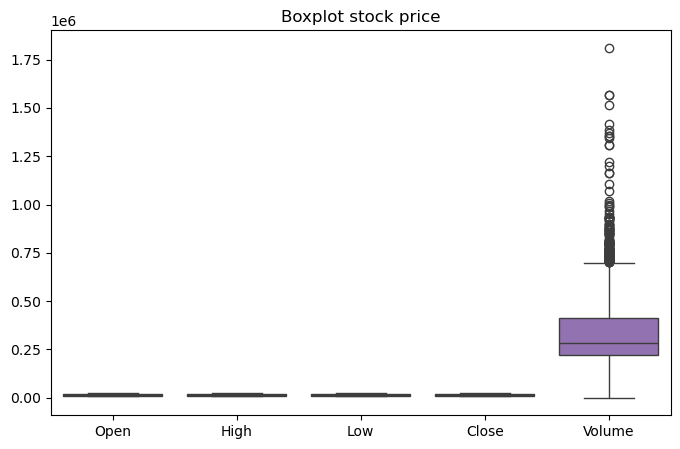

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Open','High','Low','Close','Volume']])
plt.title("Boxplot stock price")
plt.show()

## Correlation Matrix

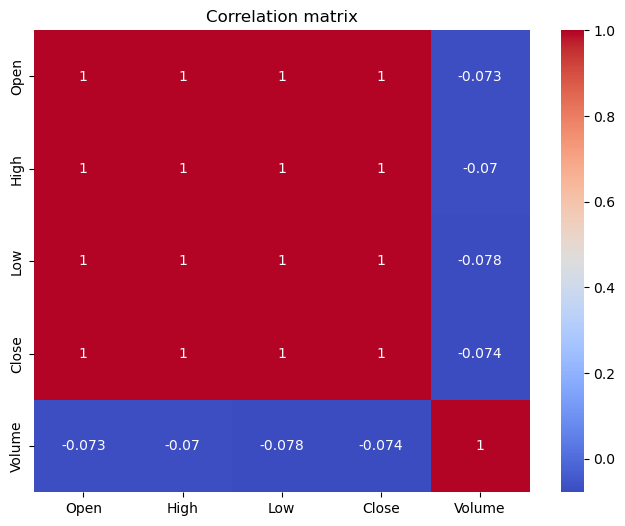

In [10]:
corr=df[['Open','High','Low','Close','Volume']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

## price trend of nifty50

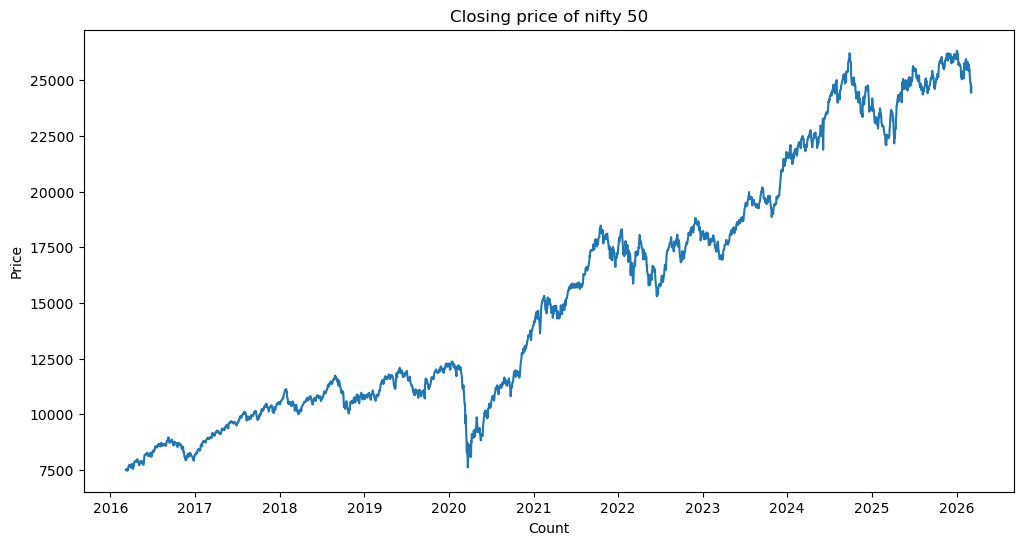

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df['Close'])
plt.title("Closing price of nifty 50")
plt.xlabel("Count")
plt.ylabel("Price")
plt.show()

## before applying models,i create some variables likes(daily return, log return)

In [12]:
df['Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Return'].rolling(30).std()
df.dropna(inplace=True) #there is not missing value but it create automatically in the first row

## Daily Log Returns

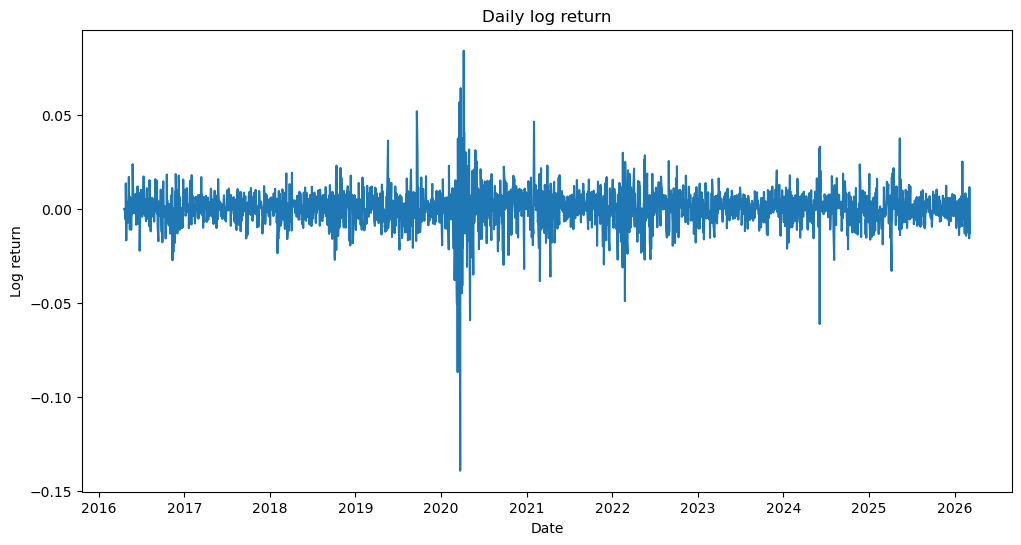

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df.index,df['Log_Return'])
plt.title("Daily log return")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.show()

## histogram graph of daily returns(how the returns of NIFTY50 are distributed)

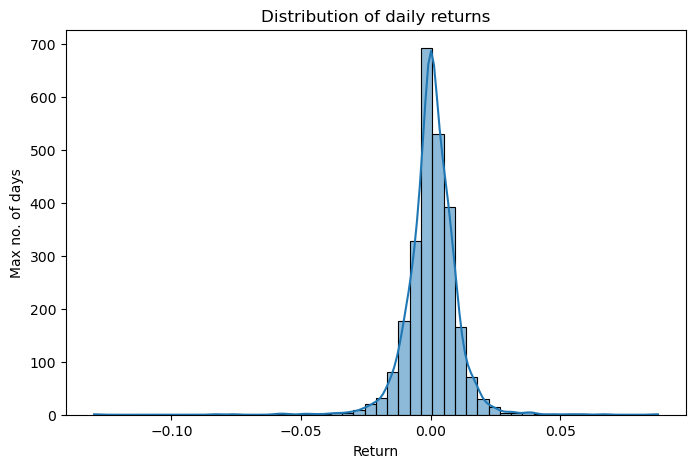

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Return'], bins=50, kde=True)
plt.title("Distribution of daily returns")
plt.xlabel("Return")
plt.ylabel("Max no. of days")
plt.show()

## again before applying models,i have created one more variable rolling volatility(means how much returns fluctuate over time) for 30 days 

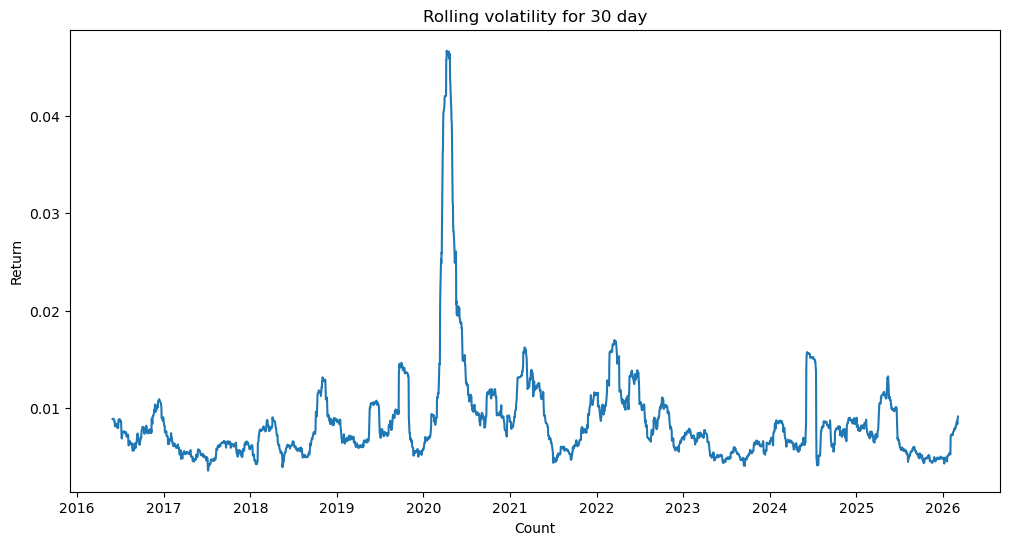

In [15]:
df['rolling_volatility'] = df['Return'].rolling(window=30).std()
plt.figure(figsize=(12,6))
plt.plot(df.index,df['rolling_volatility'])
plt.title("Rolling volatility for 30 day")
plt.xlabel("Count")
plt.ylabel("Return")
plt.show()

## ACF plot(autocorrelation plot)

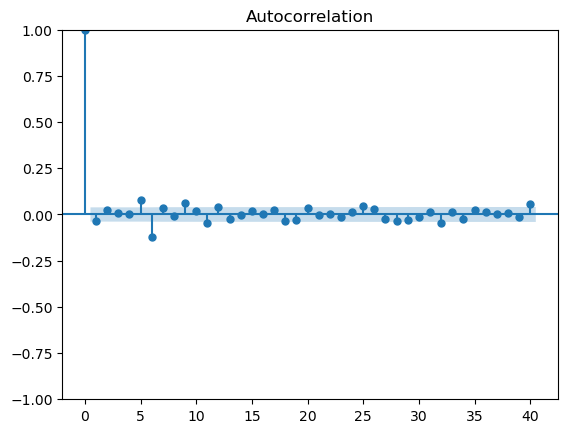

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Return'].dropna(), lags=40)
plt.show()

## PACF plot

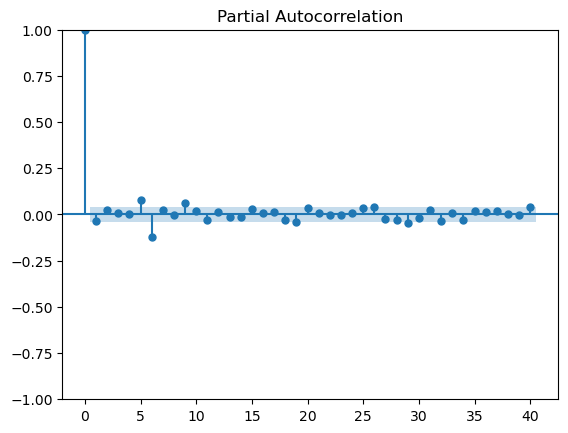

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Return'].dropna(), lags=40)
plt.show()

## check whether the series is stationary using (ADF) test 

In [18]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Close'])
print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -0.41351666123546194
p-value: 0.9078174000124252


## now differencing the series

<Axes: xlabel='Date'>

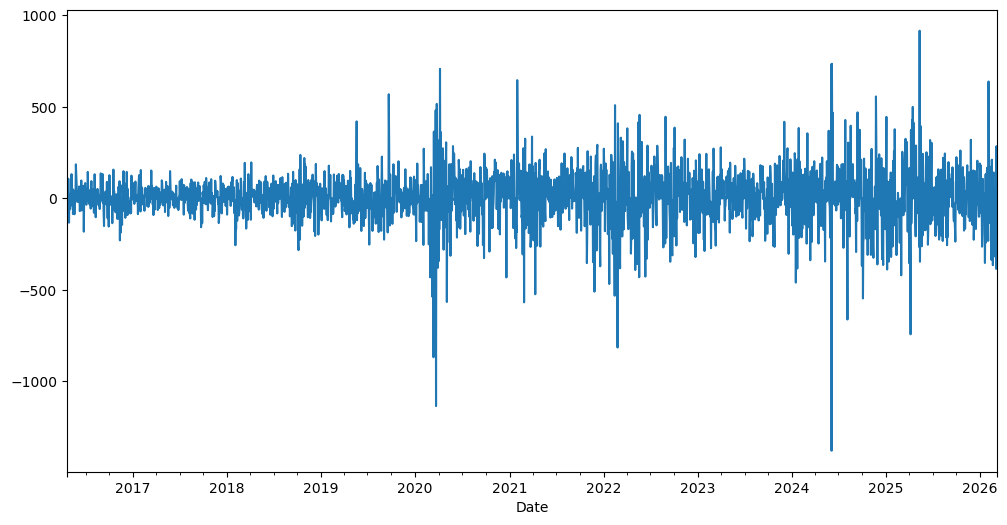

In [19]:
df['Close_diff']=df['Close'].diff()
df['Close_diff'].dropna().plot(figsize=(12,6))

## now i am spliting the dataset into two part that is "Train" and "Test"

In [20]:
train_size=int(len(df)*0.8)
train_return=df['Return'][:train_size]
test_return=df['Return'][train_size:]

## after that training the model on Return and i am applying the model that is (ARIMA model)

In [21]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error, r2_score
train_size = int(len(df) * 0.8)
train = df['Close'][:train_size]
test  = df['Close'][train_size:]
model_arima = ARIMA(train, order=(1,1,1))  # Close is non-stationary → d=1
result_arima = model_arima.fit()
pred_arima = result_arima.forecast(steps=len(test))

## now the summary of the ARIMA model

In [22]:
model=ARIMA(df['Return'], order=(1,1,1))
result=model.fit()
print(result.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 2579
Model:                 ARIMA(1, 1, 1)   Log Likelihood                8248.282
Date:                Fri, 12 Jun 2026   AIC                         -16490.564
Time:                        15:54:32   BIC                         -16472.999
Sample:                    04-19-2016   HQIC                        -16484.197
                         - 03-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0362      0.010     -3.711      0.000      -0.055      -0.017
ma.L1         -0.9998      0.015    -65.351      0.000      -1.030      -0.970
sigma2      9.701e-05    1.6e-06     60.565      0.0

## ARIMA Evaluation

In [23]:
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
mae_arima = mean_absolute_error(test, pred_arima)

mape_arima = mean_absolute_percentage_error(test, pred_arima) * 100
accuracy_arima = 100 - mape_arima
r2_arima = r2_score(test, pred_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAE:", mae_arima)
print("ARIMA MAPE:", round(mape_arima, 2), "%")
print("ARIMA Accuracy:", round(accuracy_arima, 2), "%")
print("ARIMA R2 Score:", round(r2_arima, 4))

ARIMA RMSE: 2512.314829164758
ARIMA MAE: 2231.4480809314896
ARIMA MAPE: 8.94 %
ARIMA Accuracy: 91.06 %
ARIMA R2 Score: -3.6097


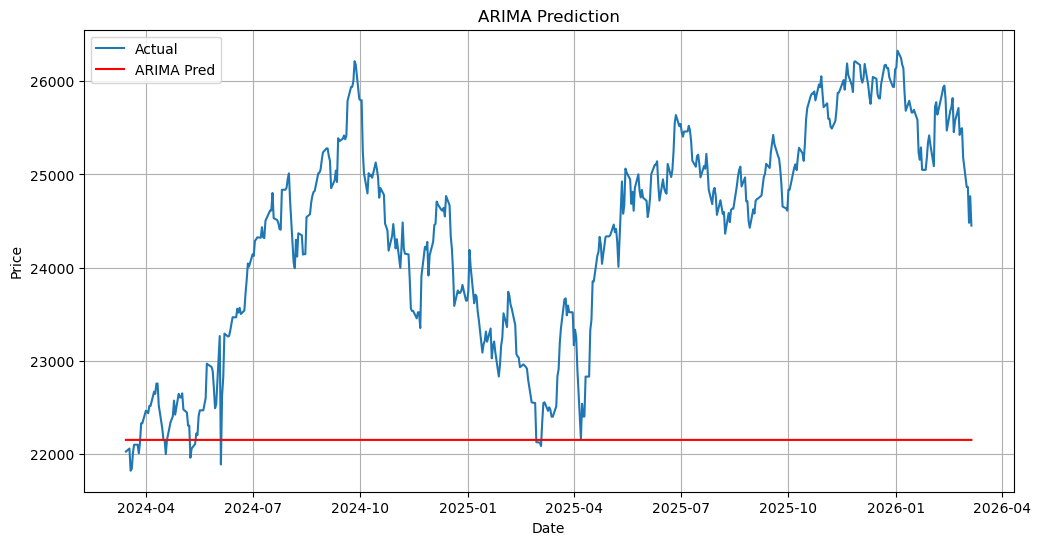

In [24]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, pred_arima, label="ARIMA Pred", color='red')
plt.title("ARIMA Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


## Preparing Data for LSTM

In [25]:
from sklearn.preprocessing import StandardScaler
data = df[['Open','High','Low','Close']]
scaler = StandardScaler()
scaled = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled, columns=data.columns, index=data.index)

## Creating Sequences

In [26]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, 3])  # Close
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df.values, 60)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2519, 60, 4)
y shape: (2519,)


## Train-Test Split

In [27]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Now the model architecture for "LSTM"

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

def direction_accuracy(y_true, y_pred):
    true_sign = tf.sign(y_true - tf.reduce_mean(y_true))
    pred_sign = tf.sign(y_pred - tf.reduce_mean(y_pred))
    return tf.reduce_mean(tf.cast(tf.equal(true_sign, pred_sign), tf.float32))

model = Sequential([Input(shape=(60,4)),LSTM(50, return_sequences=True),Dropout(0.2),LSTM(50),Dropout(0.2),Dense(25),Dense(1)])

model.compile(optimizer='adam',loss='mean_squared_error',metrics=[direction_accuracy])  # ← CHANGED

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - direction_accuracy: 0.5240 - loss: 0.0536 - val_direction_accuracy: 0.5039 - val_loss: 0.0817
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - direction_accuracy: 0.5208 - loss: 0.0100 - val_direction_accuracy: 0.5038 - val_loss: 0.0267
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - direction_accuracy: 0.5206 - loss: 0.0077 - val_direction_accuracy: 0.5035 - val_loss: 0.0072
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - direction_accuracy: 0.5211 - loss: 0.0082 - val_direction_accuracy: 0.5034 - val_loss: 0.0172
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - direction_accuracy: 0.5211 - loss: 0.0067 - val_direction_accuracy: 0.5033 - val_loss: 0.0329
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - direction_accuracy: 0.5215 - loss: 0.0061 - val_direction_accuracy: 0.5022 - val_loss: 0.0147
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - direction_accuracy: 0.5204 - loss: 0.0058 - val_direction_accura

## Loss Plot

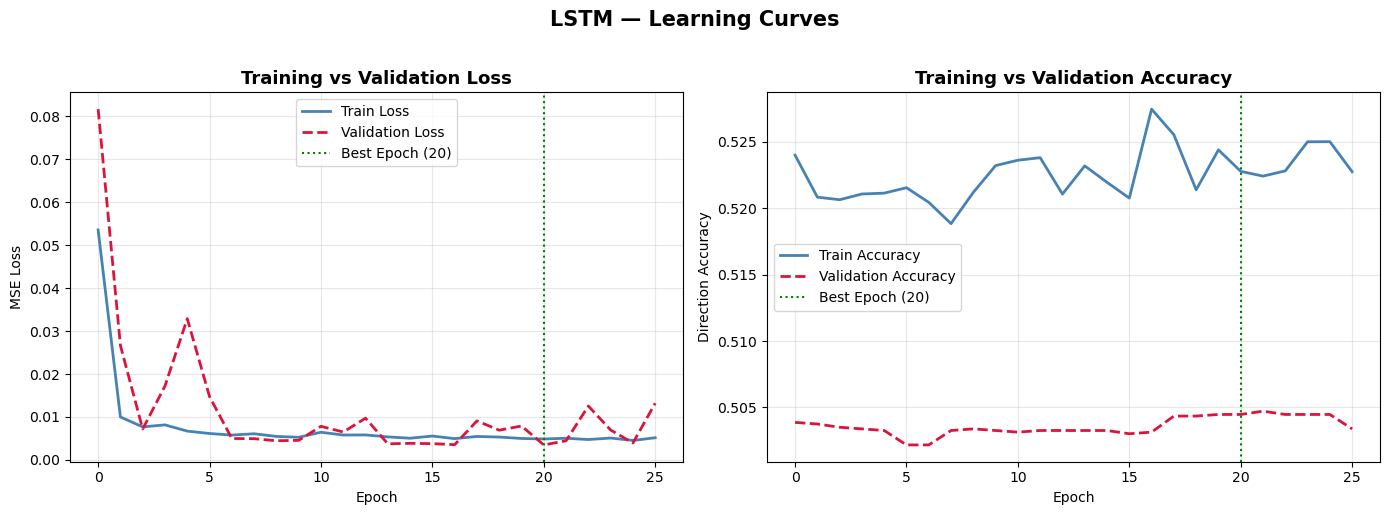

  Best Epoch: 20
  Final Train Loss: 0.005163
  Final Val Loss: 0.013198
  Final Train Acc: 52.27%
  Final Val Acc: 50.34%


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Loss
axes[0].plot(history.history['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'],
             label='Validation Loss', color='crimson',
             linewidth=2, linestyle='--')

axes[0].set_title("Training vs Validation Loss", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

best_epoch = np.argmin(history.history['val_loss'])
axes[0].axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
                label=f'Best Epoch ({best_epoch})')
axes[0].legend()

# Right plot: Accuracy
axes[1].plot(history.history['direction_accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_direction_accuracy'],
             label='Validation Accuracy', color='crimson',
             linewidth=2, linestyle='--')

axes[1].set_title("Training vs Validation Accuracy", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Direction Accuracy")
axes[1].axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
                label=f'Best Epoch ({best_epoch})')

axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("LSTM — Learning Curves", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"  Best Epoch: {best_epoch}")
print(f"  Final Train Loss: {history.history['loss'][-1]:.6f}")
print(f"  Final Val Loss: {history.history['val_loss'][-1]:.6f}")
print(f"  Final Train Acc: {history.history['direction_accuracy'][-1]*100:.2f}%")
print(f"  Final Val Acc: {history.history['val_direction_accuracy'][-1]*100:.2f}%")

## Predictions

In [30]:
pred = model.predict(X_test)
dummy = np.zeros((len(pred), 4))
dummy[:,3] = pred.flatten()
predicted_price = scaler.inverse_transform(dummy)[:,3]
dummy[:,3] = y_test
actual_price = scaler.inverse_transform(dummy)[:,3]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step 


## Evaluation

In [31]:
rmse = np.sqrt(mean_squared_error(actual_price, predicted_price))
mae  = mean_absolute_error(actual_price, predicted_price)
r2   = r2_score(actual_price, predicted_price)
print("LSTM RMSE:", rmse)
print("LSTM MAE :", mae)
print("R2 Score :", r2)


rmse = np.sqrt(mean_squared_error(actual_price, predicted_price))
mae = mean_absolute_error(actual_price, predicted_price)
r2 = r2_score(actual_price, predicted_price)

mape = mean_absolute_percentage_error(actual_price, predicted_price) * 100

accuracy = 100 - mape

print("LSTM RMSE:", rmse)
print("LSTM MAE:", mae)
print("LSTM R2:", r2)
print("LSTM MAPE:", round(mape, 2), "%")
print("LSTM Accuracy:", round(accuracy, 2), "%")

LSTM RMSE: 334.65594275906744
LSTM MAE : 266.76242779428605
R2 Score : 0.9121663114270566
LSTM RMSE: 334.65594275906744
LSTM MAE: 266.76242779428605
LSTM R2: 0.9121663114270566
LSTM MAPE: 1.1 %
LSTM Accuracy: 98.9 %


## ROC/AUC Curve for LSTM

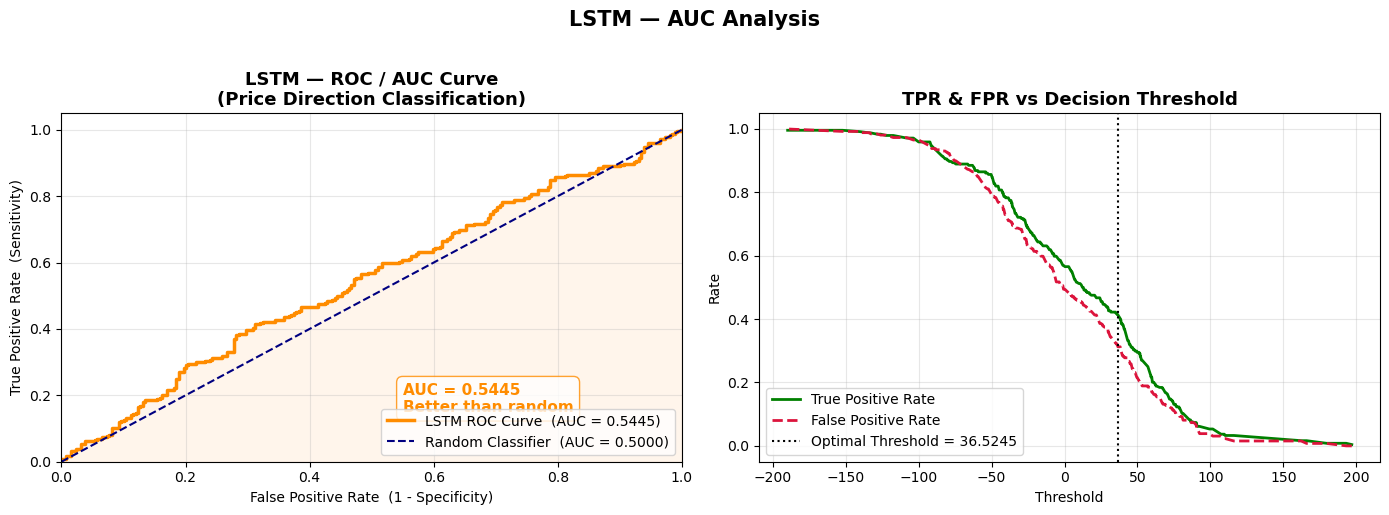

  AUC Score: 0.5445
  Optimal Threshold: 36.5245
  TPR at optimal point: 41.39%
  FPR at optimal point: 31.27%
  Interpretation       : Better than random — model has directional skill


In [32]:
from sklearn.metrics import roc_curve, auc
actual_direction = (np.diff(actual_price) > 0).astype(int)
predicted_score  = np.diff(predicted_price)
fpr, tpr, thresholds = roc_curve(actual_direction, predicted_score)
roc_auc = auc(fpr, tpr)
t = thresholds[:len(tpr)-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr,color='darkorange', linewidth=2.5,
             label=f'LSTM ROC Curve  (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1],color='navy', linewidth=1.5, linestyle='--',
             label='Random Classifier  (AUC = 0.5000)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='darkorange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_title("LSTM — ROC / AUC Curve\n(Price Direction Classification)",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("False Positive Rate  (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate  (Sensitivity)")
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[0].text(0.55, 0.15,
             f"AUC = {roc_auc:.4f}\n"
             f"{'Better than random' if roc_auc > 0.5 else 'Worse than random'}",
             fontsize=11, color='darkorange', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='darkorange', alpha=0.8))

axes[1].plot(t, tpr[:-1],color='green', linewidth=2, label='True Positive Rate')
axes[1].plot(t, fpr[:-1],color='crimson', linewidth=2, label='False Positive Rate',linestyle='--')

optimal_idx= np.argmax(tpr[:-1] - fpr[:-1])
optimal_threshold= t[optimal_idx]

axes[1].axvline(optimal_threshold, color='black', linestyle=':',linewidth=1.5,
                label=f'Optimal Threshold = {optimal_threshold:.4f}')
axes[1].set_title("TPR & FPR vs Decision Threshold",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Rate")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("LSTM — AUC Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"  AUC Score: {roc_auc:.4f}")
print(f"  Optimal Threshold: {optimal_threshold:.4f}")
print(f"  TPR at optimal point: {tpr[optimal_idx]*100:.2f}%")
print(f"  FPR at optimal point: {fpr[optimal_idx]*100:.2f}%")

interpretation = ("Better than random — model has directional skill"
                  if roc_auc > 0.5 else
                  "Below random — model struggles with direction")
print(f"  Interpretation       : {interpretation}")

## Now the final result through "Plot"

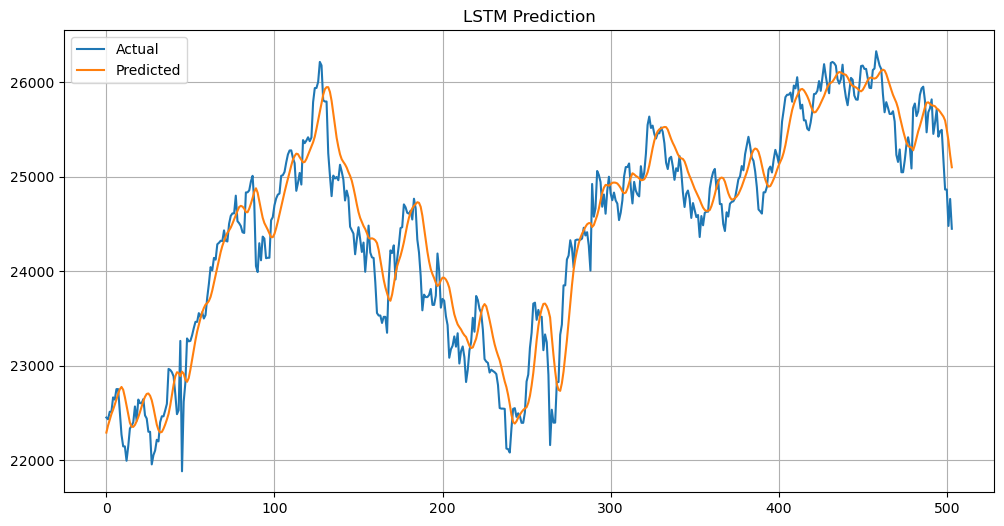

In [33]:
plt.figure(figsize=(12,6))
plt.plot(actual_price, label='Actual')
plt.plot(predicted_price, label='Predicted')
plt.title("LSTM Prediction")
plt.legend()
plt.grid(True)
plt.show()

## Buy /Sell plot signals

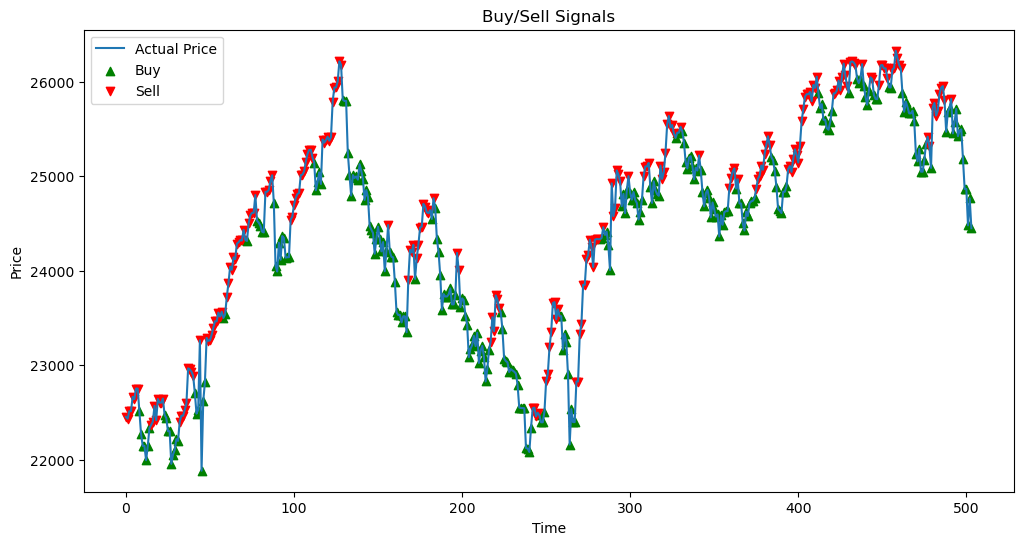

In [34]:
signals = np.where(predicted_price > actual_price, 1, -1)
plt.figure(figsize=(12,6))
plt.plot(actual_price, label='Actual Price')
buy = np.where(signals == 1)[0]
sell = np.where(signals == -1)[0]
plt.scatter(buy, actual_price[buy], color='green', marker='^', label='Buy')
plt.scatter(sell, actual_price[sell], color='red', marker='v', label='Sell')
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.title("Buy/Sell Signals")
plt.show()

## Buy /Sell signals threshold

In [35]:
threshold = 0.002
signals = np.where(
    (predicted_price - actual_price)/actual_price > threshold, 1,
    np.where(
        (predicted_price - actual_price)/actual_price < -threshold, -1, 0))

## Backtesting Strategy and Benchmark

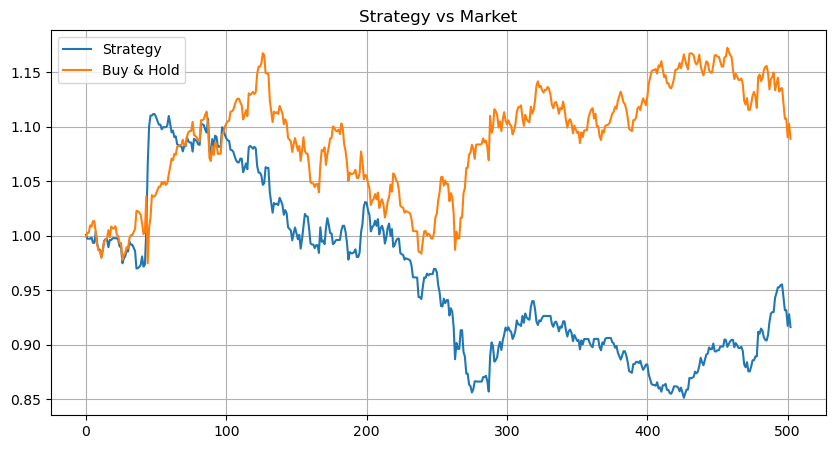

In [36]:
returns = np.diff(actual_price) / actual_price[:-1]
signals = signals[:-1]

strategy_returns = signals * returns
cum_strategy = np.cumprod(1 + strategy_returns)
buy_hold = np.cumprod(1 + returns)

plt.figure(figsize=(10,5))
plt.plot(cum_strategy, label="Strategy")
plt.plot(buy_hold, label="Buy & Hold")
plt.title("Strategy vs Market")
plt.legend()
plt.grid(True)
plt.show()

## Sharpe Ratio

In [37]:
sharpe = (np.mean(strategy_returns) / np.std(strategy_returns)) * np.sqrt(252)
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: -0.29480813684569507


## Fututre Prediction after 6 month

In [38]:
future_days = 120
current_seq = X_test[-1].copy()
future_preds = []

for _ in range(future_days):
    p = model.predict(current_seq.reshape(1,60,4))
    future_preds.append(p[0,0])

    new_row = current_seq[-1].copy()
    new_row[3] = p[0,0]   # FIXED
    current_seq = np.vstack([current_seq[1:], new_row])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

## Convert Future Prices

In [39]:
dummy = np.zeros((len(future_preds),4))
dummy[:,3] = future_preds
future_prices = scaler.inverse_transform(dummy)[:,3]

## Future Signals

In [40]:
future_signals=np.where(np.diff(future_prices) > 0, 1, -1)

## Plot Future Forecast

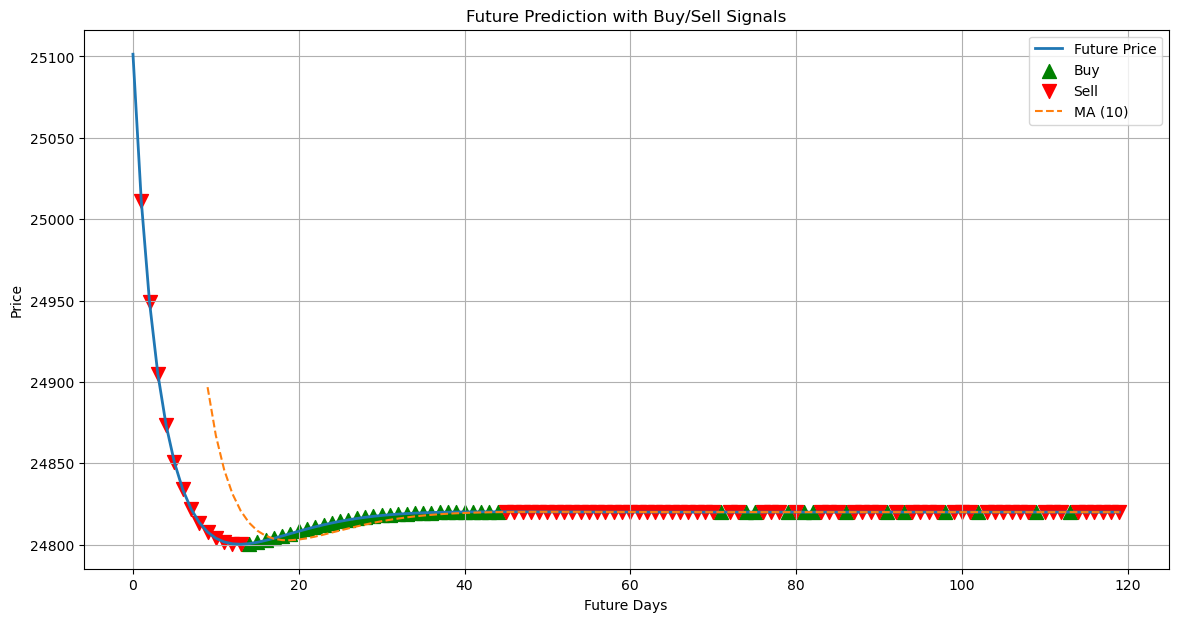

In [41]:
plt.figure(figsize=(14,7))

future_prices = np.array(future_prices)

# Price
plt.plot(future_prices, label='Future Price', linewidth=2)

# Signals
buy_idx = np.where(future_signals == 1)[0] + 1
sell_idx = np.where(future_signals == -1)[0] + 1

plt.scatter(buy_idx, future_prices[buy_idx], color='green', marker='^', s=100, label='Buy')
plt.scatter(sell_idx, future_prices[sell_idx], color='red', marker='v', s=100, label='Sell')

# Moving average
ma = pd.Series(future_prices).rolling(10).mean()
plt.plot(ma, linestyle='--', label='MA (10)')

plt.title("Future Prediction with Buy/Sell Signals")
plt.xlabel("Future Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## External Shock / Crisis Event Analysis

In [42]:
# crisis or shock periods 
crisis_events = {"COVID Crash": ("2020-03-01", "2020-06-30"),
    "Russia-Ukraine War"  : ("2022-02-24", "2022-03-31"),
    "Global Recession Fear": ("2022-06-01", "2022-10-31")}

df['shock'] = 0
for event, (start, end) in crisis_events.items():
    mask = (df.index >= start) & (df.index <= end)
    df.loc[mask, 'shock'] = 1
    count = mask.sum()
    print(f"{event}: {start} → {end}  ({count} trading days marked)")

print(f"\nTotal shock days : {df['shock'].sum()}")
print(f"Total normal days: {(df['shock']==0).sum()}")

COVID Crash: 2020-03-01 → 2020-06-30  (87 trading days marked)
Russia-Ukraine War: 2022-02-24 → 2022-03-31  (26 trading days marked)
Global Recession Fear: 2022-06-01 → 2022-10-31  (109 trading days marked)

Total shock days : 222
Total normal days: 2357


## Visualise crisis periods on the price chart

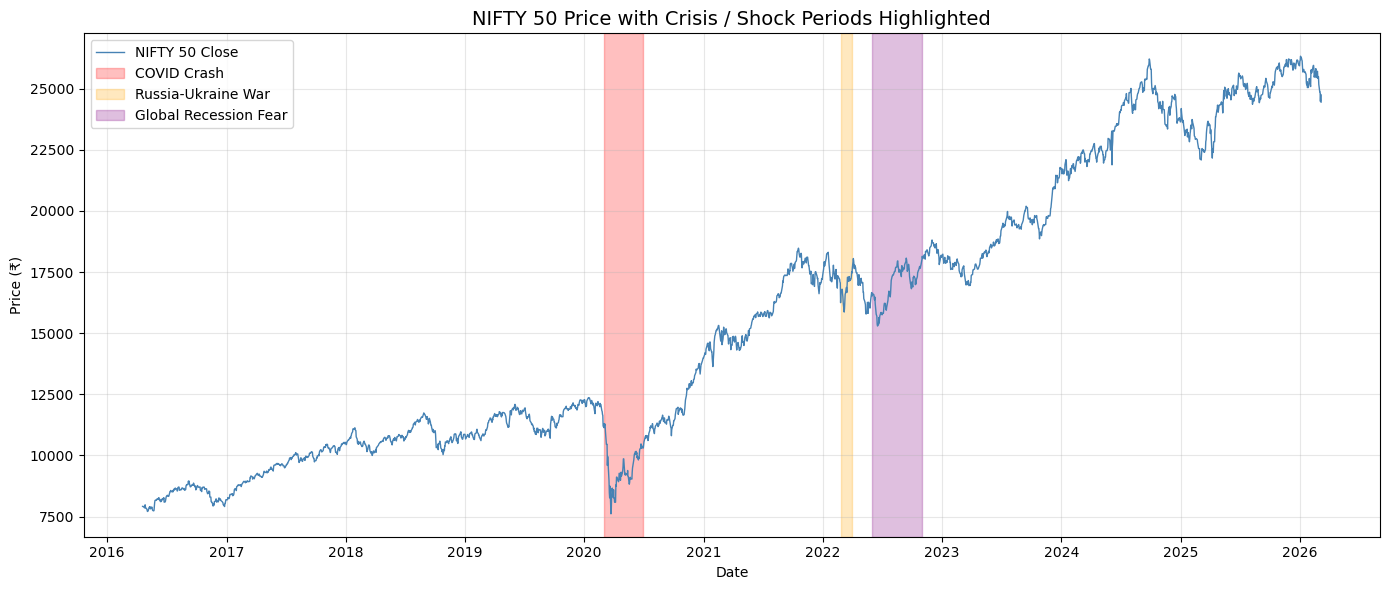

In [43]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1, label='NIFTY 50 Close')

colors = ['red', 'orange', 'purple']
for i, (event, (start, end)) in enumerate(crisis_events.items()):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),alpha=0.25, color=colors[i], label=event)

ax.set_title("NIFTY 50 Price with Crisis / Shock Periods Highlighted", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (₹)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2: ARIMAX - ARIMA with Exogenous (Shock) Variable

In [44]:
from statsmodels.tsa.arima.model import ARIMA

train_size_ax = int(len(df) * 0.8)
train_ax = df['Close'][:train_size_ax]
test_ax  = df['Close'][train_size_ax:]
shock_train = df['shock'][:train_size_ax]
shock_test  = df['shock'][train_size_ax:]

# Fit ARIMAX(1,1,1) with shock as exogenous variable
model_arimax = ARIMA(train_ax, order=(1, 1, 1), exog=shock_train)
result_arimax = model_arimax.fit()

pred_arimax = result_arimax.forecast(steps=len(test_ax), exog=shock_test)

print(result_arimax.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2063
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -12929.769
Date:                Fri, 12 Jun 2026   AIC                          25867.538
Time:                        15:56:30   BIC                          25890.064
Sample:                    04-19-2016   HQIC                         25875.796
                         - 03-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
shock       -235.4919     25.637     -9.186      0.000    -285.739    -185.244
ar.L1         -0.0511      1.371     -0.037      0.970      -2.739       2.637
ma.L1          0.0602      1.368      0.044      0.9

In [45]:
rmse_arimax= np.sqrt(mean_squared_error(test_ax, pred_arimax))
mae_arimax= mean_absolute_error(test_ax, pred_arimax)
mape_arimax= np.mean(np.abs((test_ax.values - pred_arimax.values) / test_ax.values)) * 100
accuracy_arimax= 100 - mape_arimax
r2_arimax= r2_score(test_ax, pred_arimax)
print("ARIMAX Evaluation Metrics")
print(f"RMSE: {rmse_arimax:.4f}")
print(f"MAE: {mae_arimax:.4f}")
print(f"MAPE: {mape_arimax:.2f}%")
print(f"Accuracy: {accuracy_arimax:.2f}%")
print(f"R2 Score: {r2_arimax:.4f}")

ARIMAX Evaluation Metrics
RMSE: 2512.6613
MAE: 2231.8095
MAPE: 8.95%
Accuracy: 91.05%
R2 Score: -3.6110


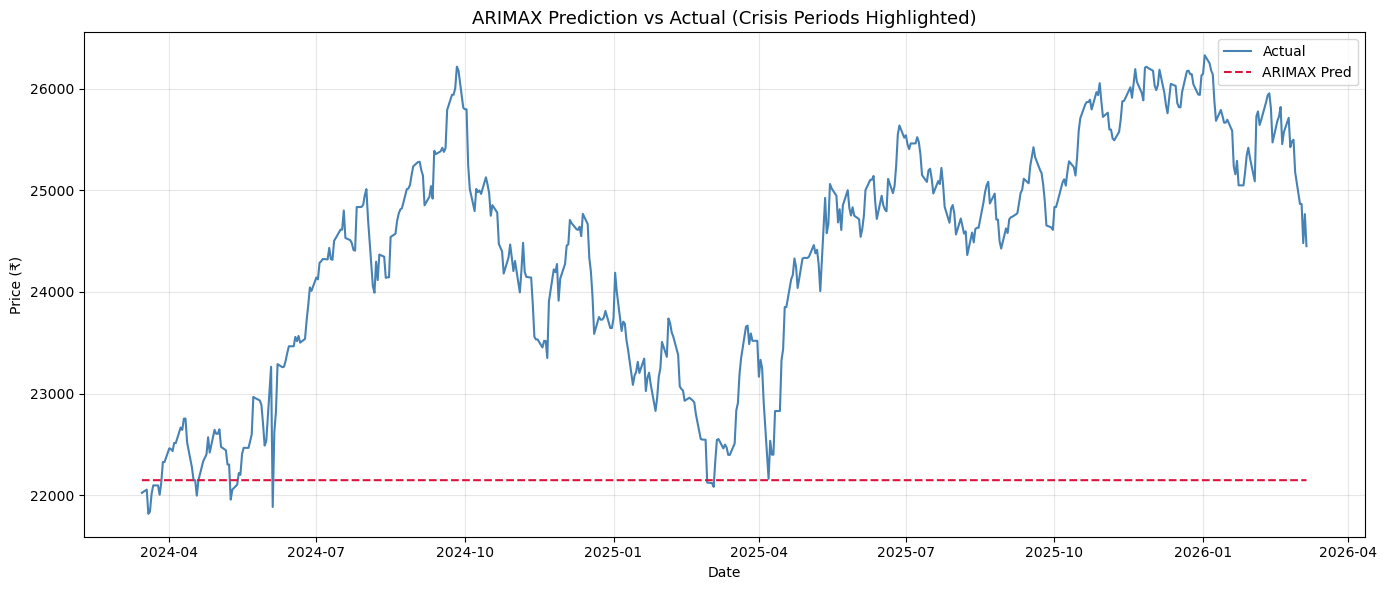

In [46]:
# ARIMAX Actual vs Predicted 
plt.figure(figsize=(14, 6))
plt.plot(test_ax.index, test_ax.values,       label='Actual',        color='steelblue')
plt.plot(test_ax.index, pred_arimax.values,   label='ARIMAX Pred',   color='crimson', linestyle='--')

for event, (start, end) in crisis_events.items():
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    if s < test_ax.index[-1] and e > test_ax.index[0]:
        ax_shade_s = max(s, test_ax.index[0])
        ax_shade_e = min(e, test_ax.index[-1])
        plt.axvspan(ax_shade_s, ax_shade_e, alpha=0.2, color='orange', label=f'Crisis: {event}')

plt.title("ARIMAX Prediction vs Actual (Crisis Periods Highlighted)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Simulate: What if a NEW 1-Month War Starts Tomorrow?

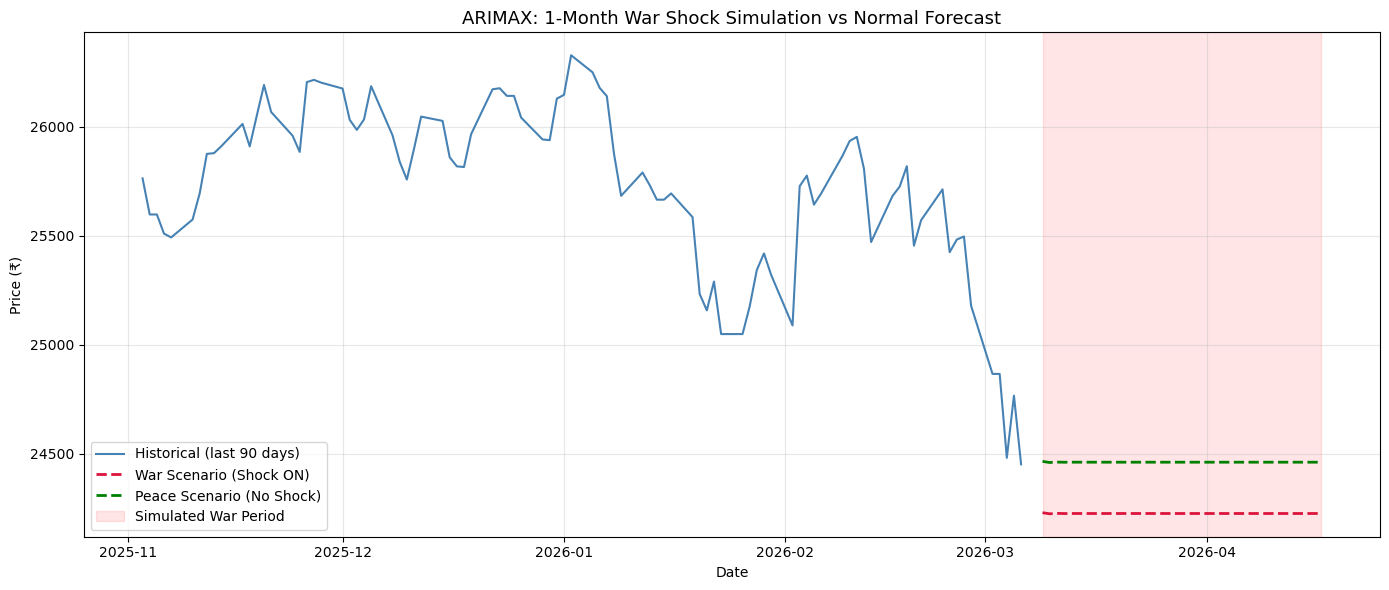

Estimated price impact of war shock : ₹235.49 drop
As percentage : 0.96% downward movement


In [47]:
future_shock_days = 30
future_exog_shock = np.ones(future_shock_days)
model_full_arimax = ARIMA(df['Close'], order=(1, 1, 1), exog=df['shock'])
result_full_arimax = model_full_arimax.fit()
forecast_war = result_full_arimax.forecast(steps=future_shock_days,
                                           exog=future_exog_shock)

future_exog_peace = np.zeros(future_shock_days)
forecast_peace = result_full_arimax.forecast(steps=future_shock_days,exog=future_exog_peace)

last_date   = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.offsets.BDay(1),
                               periods=future_shock_days)

plt.figure(figsize=(14, 6))
plt.plot(df.index[-90:], df['Close'].iloc[-90:],
         label='Historical (last 90 days)', color='steelblue', linewidth=1.5)
plt.plot(future_dates, forecast_war,
         label='War Scenario (Shock ON)',   color='crimson',  linewidth=2, linestyle='--')
plt.plot(future_dates, forecast_peace,
         label='Peace Scenario (No Shock)', color='green',    linewidth=2, linestyle='--')
plt.axvspan(future_dates[0], future_dates[-1], alpha=0.1, color='red', label='Simulated War Period')

plt.title("ARIMAX: 1-Month War Shock Simulation vs Normal Forecast", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

price_diff = forecast_peace.mean() - forecast_war.mean()
pct_drop   = (price_diff / forecast_peace.mean()) * 100
print(f"Estimated price impact of war shock : ₹{price_diff:.2f} drop")
print(f"As percentage : {pct_drop:.2f}% downward movement")

### Step 3: GARCH Model — Volatility During Crisis Periods

In [48]:
try:
    from arch import arch_model
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "arch", "-q"])
    from arch import arch_model
returns_pct = df['Return'].dropna() * 100

# Fit GARCH(1,1) model
garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='normal')
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3153.08
Distribution:                  Normal   AIC:                           6314.17
Method:            Maximum Likelihood   BIC:                           6337.59
                                        No. Observations:                 2579
Date:                Fri, Jun 12 2026   Df Residuals:                     2578
Time:                        15:56:32   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0704  1.619e-02      4.352  1.347e-05 [3.872e-0

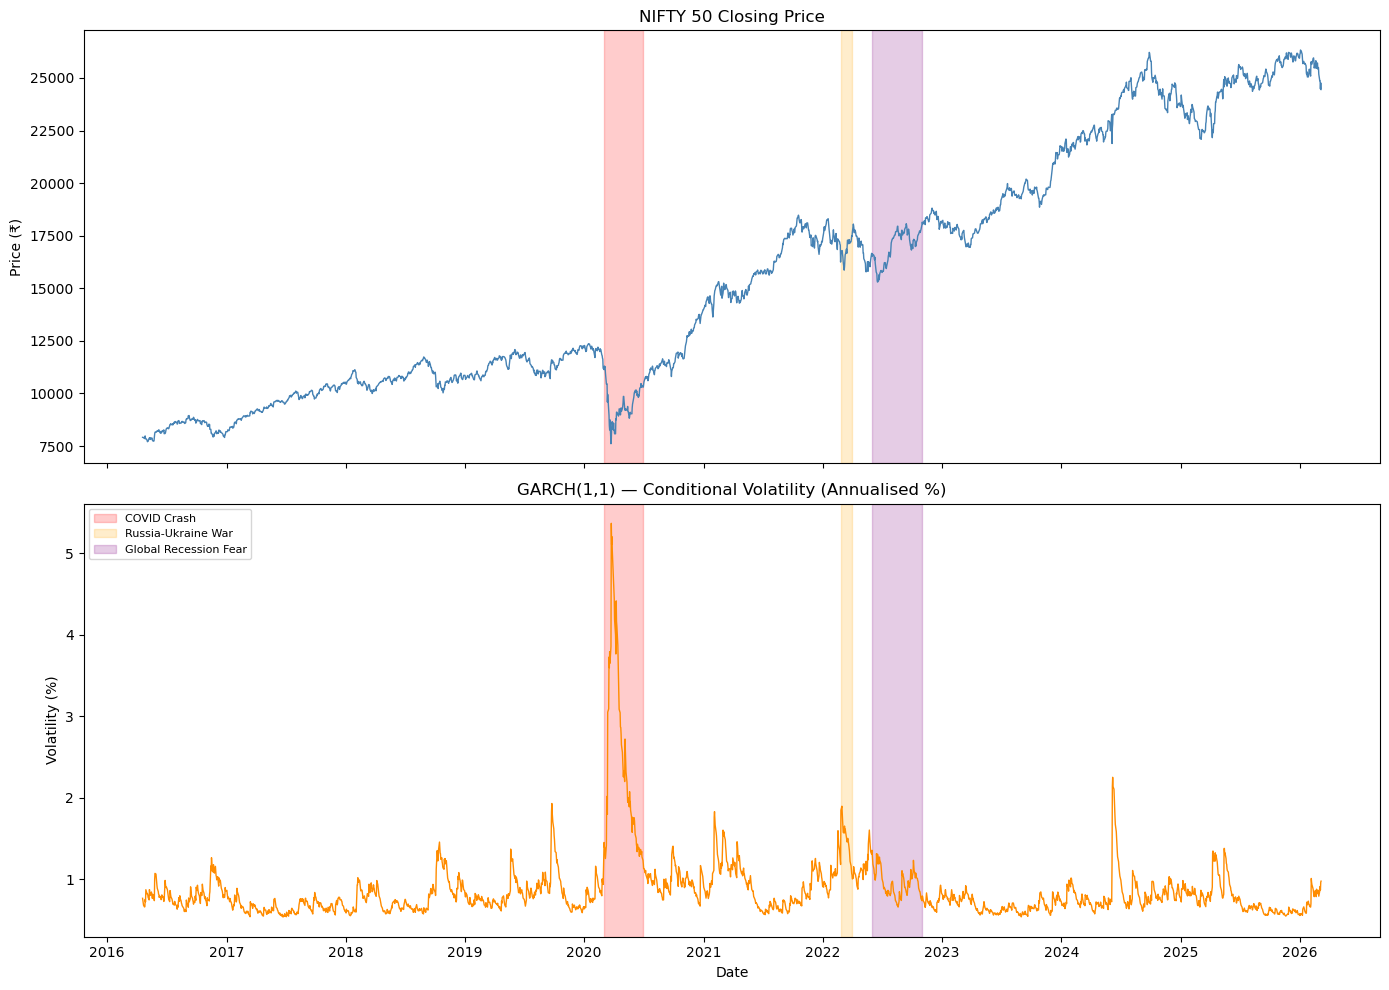


 Peak Volatility During Each Crisis Period:
  COVID Crash                   : 5.3699%
  Russia-Ukraine War            : 1.8962%
  Global Recession Fear         : 1.3134%


In [49]:
cond_vol = garch_result.conditional_volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title("NIFTY 50 Closing Price", fontsize=12)
axes[0].set_ylabel("Price (₹)")
axes[1].plot(cond_vol.index, cond_vol.values, color='darkorange', linewidth=1)
axes[1].set_title("GARCH(1,1) — Conditional Volatility (Annualised %)", fontsize=12)
axes[1].set_ylabel("Volatility (%)")
axes[1].set_xlabel("Date")

# Shade crisis zones on both subplots
for ax in axes:
    for i, (event, (start, end)) in enumerate(crisis_events.items()):
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.2, color=colors[i], label=event)

axes[1].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
print("\n Peak Volatility During Each Crisis Period:")
for event, (start, end) in crisis_events.items():
    peak = cond_vol.loc[start:end].max()
    print(f"  {event:30s}: {peak:.4f}%")

## Forecast volatility for next 30 days (war simulation) 

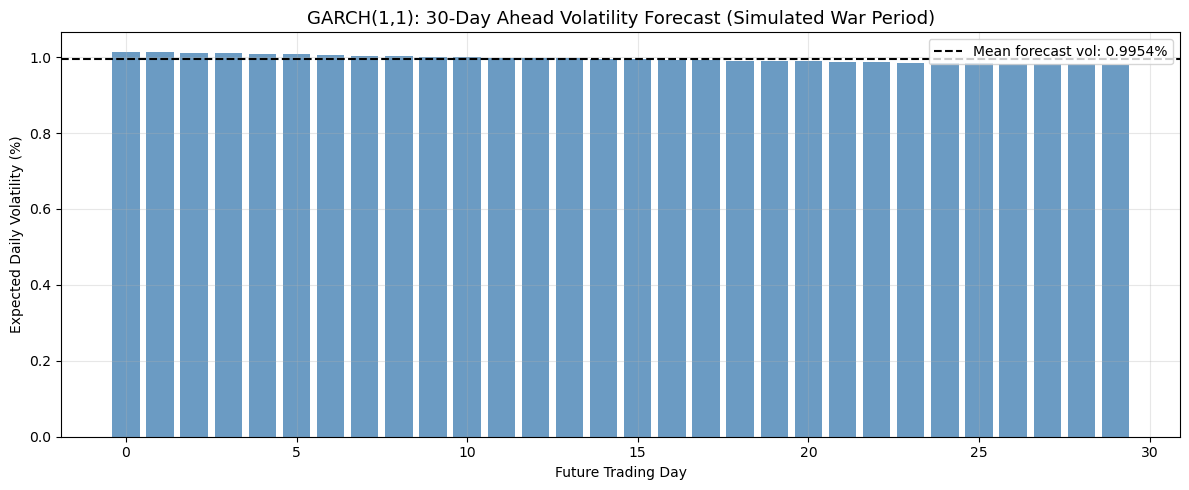


  Average forecast volatility : 0.9954%  →  MEDIUM RISK
  Peak forecast volatility    : 1.0145%
  Interpretation: During a 1-month war shock, daily price swings of
  ±1.99% to ±2.03% can be expected (2-sigma range)


In [50]:
horizon = 30
vol_forecast = garch_result.forecast(horizon=horizon, reindex=False)
forecast_variance = vol_forecast.variance.values[-1]
forecast_vol      = np.sqrt(forecast_variance)   # std dev (volatility)

future_dates_g = pd.bdate_range(start=df.index[-1] + pd.offsets.BDay(1),
                                 periods=horizon)

plt.figure(figsize=(12, 5))
plt.bar(range(horizon), forecast_vol,
        color=['crimson' if v > forecast_vol.mean() * 1.2 else 'steelblue'
               for v in forecast_vol],
        alpha=0.8)
plt.axhline(forecast_vol.mean(), color='black', linestyle='--',
            linewidth=1.5, label=f'Mean forecast vol: {forecast_vol.mean():.4f}%')
plt.title("GARCH(1,1): 30-Day Ahead Volatility Forecast (Simulated War Period)", fontsize=13)
plt.xlabel("Future Trading Day")
plt.ylabel("Expected Daily Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

avg_vol    = forecast_vol.mean()
max_vol    = forecast_vol.max()
risk_level = "HIGH RISK" if avg_vol > 1.5 else ("MEDIUM RISK" if avg_vol > 0.8 else "LOW RISK")
print(f"\n  Average forecast volatility : {avg_vol:.4f}%  →  {risk_level}")
print(f"  Peak forecast volatility    : {max_vol:.4f}%")
print(f"  Interpretation: During a 1-month war shock, daily price swings of")
print(f"  ±{avg_vol*2:.2f}% to ±{max_vol*2:.2f}% can be expected (2-sigma range)")

### Step 4: Anomaly Detection — Isolation Forest

In [51]:
from sklearn.ensemble import IsolationForest
features = df[['Return', 'Log_Return', 'Volatility']].dropna().copy()
iso_forest = IsolationForest(n_estimators=200, contamination=0.02,
                              random_state=42)
feature_cols = ['Return', 'Log_Return', 'Volatility']
features['anomaly'] = iso_forest.fit_predict(features[feature_cols])
features['anomaly_score'] = iso_forest.score_samples(features[feature_cols])
n_anomalies = (features['anomaly'] == -1).sum()
print(f" Total anomalous days detected : {n_anomalies}")
print(f" Total normal days : {(features['anomaly'] == 1).sum()}")
print(f" Anomaly rate : {n_anomalies/len(features)*100:.2f}%")

 Total anomalous days detected : 52
 Total normal days : 2527
 Anomaly rate : 2.02%


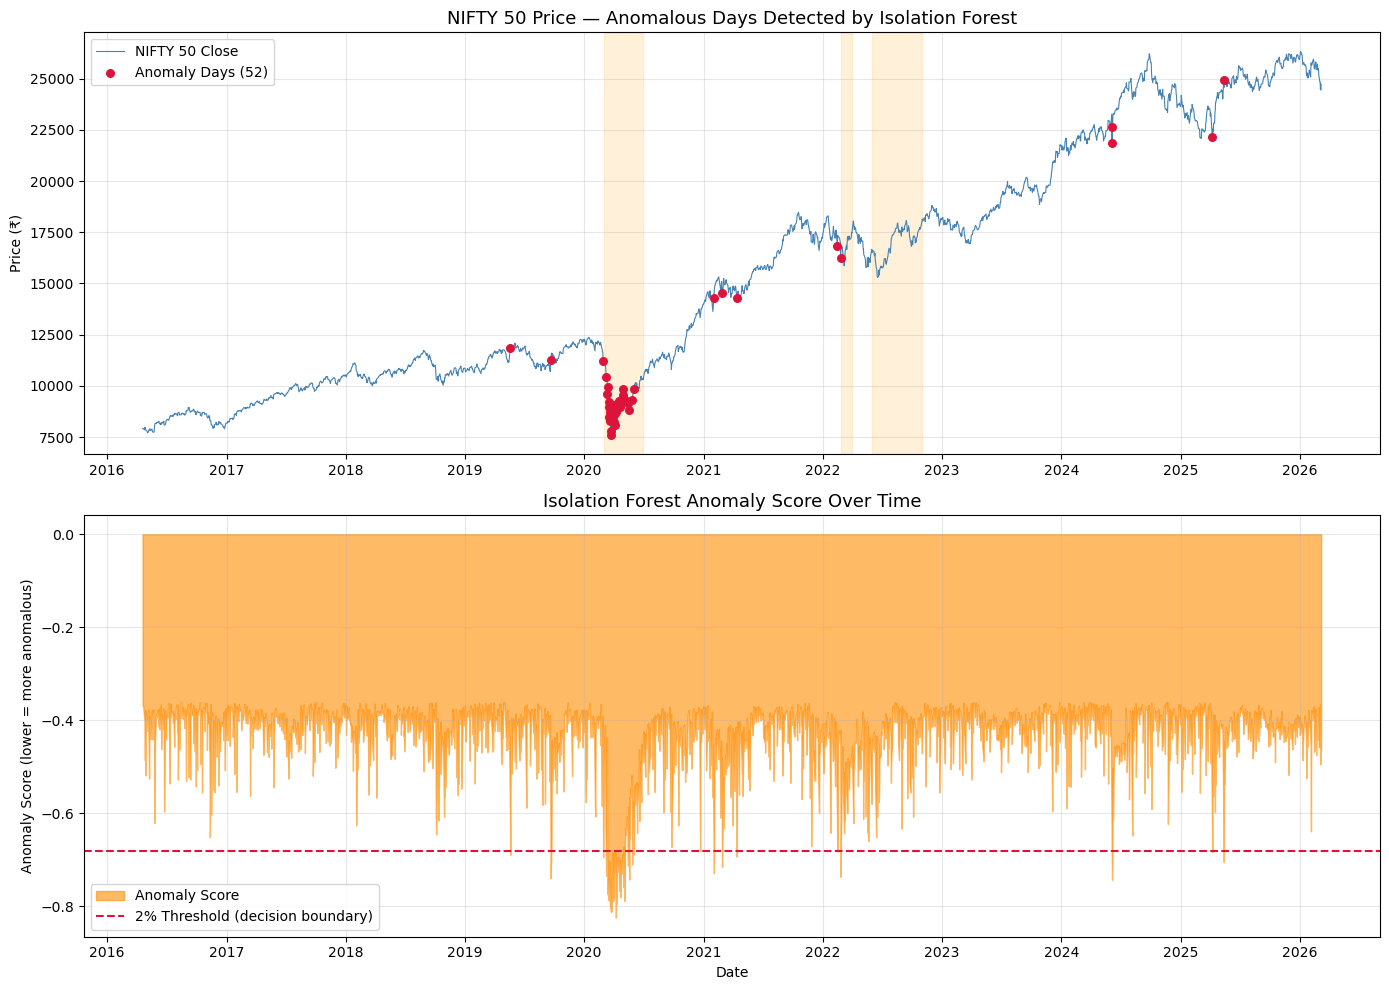

In [52]:
close_aligned = df['Close'].loc[features.index]

anomaly_idx = features[features['anomaly'] == -1].index
normal_idx  = features[features['anomaly'] ==  1].index

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(close_aligned.index, close_aligned.values,
             color='steelblue', linewidth=0.8, label='NIFTY 50 Close')
axes[0].scatter(anomaly_idx, close_aligned.loc[anomaly_idx],
                color='crimson', s=30, zorder=5, label=f'Anomaly Days ({n_anomalies})')

for event, (start, end) in crisis_events.items():
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.15, color='orange')

axes[0].set_title("NIFTY 50 Price — Anomalous Days Detected by Isolation Forest", fontsize=13)
axes[0].set_ylabel("Price (₹)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].fill_between(features.index, features['anomaly_score'],
                     alpha=0.6, color='darkorange', label='Anomaly Score')
axes[1].axhline(features['anomaly_score'].quantile(0.02),
                color='crimson', linestyle='--', linewidth=1.5,
                label='2% Threshold (decision boundary)')
axes[1].set_title("Isolation Forest Anomaly Score Over Time", fontsize=13)
axes[1].set_ylabel("Anomaly Score (lower = more anomalous)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
print("Anomaly Detection Coverage of Known Crisis Periods:")
for event, (start, end) in crisis_events.items():
    period_days  = features.loc[start:end]
    total        = len(period_days)
    caught       = (period_days['anomaly'] == -1).sum()
    pct          = caught / total * 100 if total > 0 else 0
    print(f" {event}")
    print(f" → {caught}/{total} days flagged as anomalous ({pct:.1f}%)")
print()
print("High coverage = model correctly identifies the shock period")
print("even without being told the dates explicitly.")

Anomaly Detection Coverage of Known Crisis Periods:
 COVID Crash
 → 40/87 days flagged as anomalous (46.0%)
 Russia-Ukraine War
 → 1/26 days flagged as anomalous (3.8%)
 Global Recession Fear
 → 0/109 days flagged as anomalous (0.0%)

High coverage = model correctly identifies the shock period
even without being told the dates explicitly.


 Simulated 1-Month War Period — Isolation Forest Results:
 Anomalous days flagged : 19 / 30
 Average anomaly score  : -0.6897



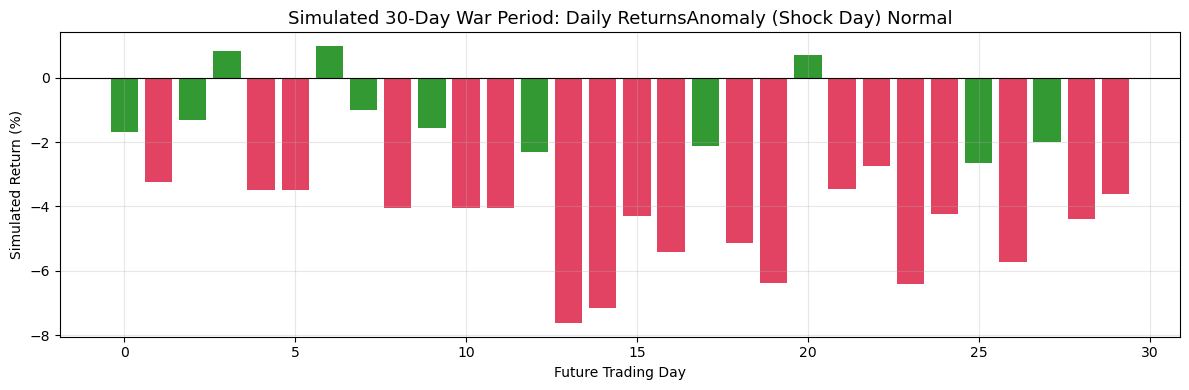

  Interpretation: 19/30 days during the simulated war are
  classified as ANOMALOUS — confirming the model detects the shock.


In [54]:
np.random.seed(42)
normal_return_mean = df['Return'].mean()
normal_return_std  = df['Return'].std()
shock_return_mean  = normal_return_mean - 3 * normal_return_std  # strong downward
shock_return_std   = normal_return_std  * 2.5                    # volatility doubles

future_returns_war = np.random.normal(shock_return_mean, shock_return_std, 30)
future_log_war     = np.log(1 + future_returns_war)
future_vol_war     = pd.Series(future_returns_war).rolling(5, min_periods=1).std().values

future_df_war = pd.DataFrame({'Return': future_returns_war,
    'Log_Return' : future_log_war,
    'Volatility' : future_vol_war})

future_labels = iso_forest.predict(future_df_war)
future_scores  = iso_forest.score_samples(future_df_war)

flagged = (future_labels == -1).sum()
print(f" Simulated 1-Month War Period — Isolation Forest Results:")
print(f" Anomalous days flagged : {flagged} / 30")
print(f" Average anomaly score  : {future_scores.mean():.4f}")
print()

colors_flag = ['crimson' if l == -1 else 'green' for l in future_labels]
plt.figure(figsize=(12, 4))
plt.bar(range(30), future_returns_war * 100, color=colors_flag, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Simulated 30-Day War Period: Daily ReturnsAnomaly (Shock Day) Normal", fontsize=13)
plt.xlabel("Future Trading Day")
plt.ylabel("Simulated Return (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"  Interpretation: {flagged}/30 days during the simulated war are")
print(f"  classified as ANOMALOUS — confirming the model detects the shock.")

## Final Summary — All Three Shock Detection Techniques

In [55]:
import warnings
warnings.filterwarnings('ignore')

# ARIMA
rmse_arima_orig = np.sqrt(mean_squared_error(test_ax, pred_arima[:len(test_ax)]))
mae_arima_orig  = mean_absolute_error(test_ax, pred_arima[:len(test_ax)])

summary_data = {"Model"       : ["ARIMA (baseline)", "ARIMAX (with shock flag)", "GARCH (volatility)", "Isolation Forest"],
    "Purpose": ["Price level forecast",
                     "Price forecast + crisis effect",
                     "Volatility / Risk forecast",
                     "Automatic anomaly detection"],
    "RMSE / Metric": [f"{rmse_arima_orig:.2f}",
                      f"{rmse_arimax:.2f}",
                      f"Avg vol: {avg_vol:.4f}%",
                      f"{flagged}/30 war days flagged"],
    "Crisis Aware": ["No", "Yes", "Yes", "Yes"]}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print(f"ARIMAX estimated price drop during 1-month war : {pct_drop:.2f}%")
print(f"GARCH peak volatility forecast : {max_vol:.4f}%")
print(f"Isolation Forest war day detection rate: {flagged/30*100:.1f}%")

                   Model                        Purpose          RMSE / Metric Crisis Aware
        ARIMA (baseline)           Price level forecast                2512.31           No
ARIMAX (with shock flag) Price forecast + crisis effect                2512.66          Yes
      GARCH (volatility)     Volatility / Risk forecast       Avg vol: 0.9954%          Yes
        Isolation Forest    Automatic anomaly detection 19/30 war days flagged          Yes
ARIMAX estimated price drop during 1-month war : 0.96%
GARCH peak volatility forecast : 1.0145%
Isolation Forest war day detection rate: 63.3%


## PART 4: 3-Month Future Price Prediction ( 63 Trading Days)

### Step 1: LSTM 3-Month Price Forecast

In [56]:
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler

FORECAST_DAYS = 63
current_seq = X_test[-1].copy()
lstm_future_preds = []

for _ in range(FORECAST_DAYS):
    p = model.predict(current_seq.reshape(1, 60, 4), verbose=0)
    lstm_future_preds.append(p[0, 0])
    new_row = current_seq[-1].copy()
    new_row[3] = p[0, 0]
    current_seq = np.vstack([current_seq[1:], new_row])
dummy = np.zeros((FORECAST_DAYS, 4))
dummy[:, 3] = lstm_future_preds
lstm_future_prices = scaler.inverse_transform(dummy)[:, 3]

print(f"  LSTM 3-month forecast generated: {FORECAST_DAYS} days")
print(f"  Last known price : ₹{actual_price[-1]:,.2f}")
print(f"  Forecast of Tommorow   : ₹{lstm_future_prices[0]:,.2f}")
print(f"  Forecast after 3month   : ₹{lstm_future_prices[-1]:,.2f}")
change_pct = (lstm_future_prices[-1] - actual_price[-1]) / actual_price[-1] * 100
direction  = "UP" if change_pct > 0 else "DOWN"
print(f"  Expected change  : {change_pct:+.2f}%  {direction}")

  LSTM 3-month forecast generated: 63 days
  Last known price : ₹24,450.45
  Forecast of Tommorow   : ₹25,101.39
  Forecast after 3month   : ₹24,820.05
  Expected change  : +1.51%  UP


## Confidence Interval

In [57]:
residuals     = actual_price - predicted_price
residual_std  = np.std(residuals)
widening      = np.linspace(1.0, 2.0, FORECAST_DAYS)
upper_band    = lstm_future_prices + widening * residual_std
lower_band    = lstm_future_prices - widening * residual_std

print(f"  Residual std (test set)     : ₹{residual_std:,.2f}")
print(f"  Day-1(0.5% CI) band  : ₹{lower_band[0]:,.2f}  –  ₹{upper_band[0]:,.2f}")
print(f"  Day-63(0.95% CI) band  : ₹{lower_band[-1]:,.2f}  –  ₹{upper_band[-1]:,.2f}")

  Residual std (test set)     : ₹327.54
  Day-1(0.5% CI) band  : ₹24,773.85  –  ₹25,428.92
  Day-63(0.95% CI) band  : ₹24,164.98  –  ₹25,475.12


In [58]:
rmse = np.sqrt(mean_squared_error(actual_price, predicted_price))
mae = mean_absolute_error(actual_price, predicted_price)
r2 = r2_score(actual_price, predicted_price)
mape = mean_absolute_percentage_error(actual_price, predicted_price) * 100
accuracy = 100 - mape
print("After Shock")
print("LSTM RMSE :", rmse)
print("LSTM MAE  :", mae)
print("LSTM R²   :", r2)
print("LSTM MAPE :", round(mape, 2), "%")
print("LSTM Accuracy :", round(accuracy, 2), "%")

After Shock
LSTM RMSE : 334.65594275906744
LSTM MAE  : 266.76242779428605
LSTM R²   : 0.9121663114270566
LSTM MAPE : 1.1 %
LSTM Accuracy : 98.9 %


## Step 2: ARIMAX — 3-Month Price Forecast (No Active Shock).

In [59]:
from statsmodels.tsa.arima.model import ARIMA
model_3m_arimax= ARIMA(df['Close'], order=(1, 1, 1), exog=df['shock'])
result_3m_arimax= model_3m_arimax.fit()

future_shock_3m= np.zeros(FORECAST_DAYS) 
arimax_3m_forecast= result_3m_arimax.forecast(steps=FORECAST_DAYS,
                                                exog=future_shock_3m)

forecast_obj= result_3m_arimax.get_forecast(steps=FORECAST_DAYS,
                                               exog=future_shock_3m)
conf_int= forecast_obj.conf_int(alpha=0.10)   # 90% CI
arimax_lower= conf_int.iloc[:, 0].values
arimax_upper= conf_int.iloc[:, 1].values

print(f"ARIMAX 3-month forecast generated: {FORECAST_DAYS} days")
print(f"Forecast after 3 month  : ₹{arimax_3m_forecast.iloc[-1]:,.2f}")
arimax_change= (arimax_3m_forecast.iloc[-1] - df['Close'].iloc[-1]) / df['Close'].iloc[-1] * 100
direction_ax= "UP" if arimax_change > 0 else "DOWN"
print(f"Expected change: {arimax_change:+.2f}%  {direction_ax}")

ARIMAX 3-month forecast generated: 63 days
Forecast after 3 month  : ₹24,460.44
Expected change: +0.04%  UP


In [60]:
accuracy_arimax = 100 - mape_arimax
r2_arimax = r2_score(test_ax, pred_arimax)

print("ARIMAX Evaluation Metrics After Shock")
print(f"RMSE: {rmse_arimax:.4f}")
print(f"MAE: {mae_arimax:.4f}")
print(f"MAPE: {mape_arimax:.2f}%")
print(f"Accuracy: {accuracy_arimax:.2f}%")
print(f"R2 Score: {r2_arimax:.4f}")

ARIMAX Evaluation Metrics After Shock
RMSE: 2512.6613
MAE: 2231.8095
MAPE: 8.95%
Accuracy: 91.05%
R2 Score: -3.6110


### Step 3: Combined 3-Month Forecast Plot

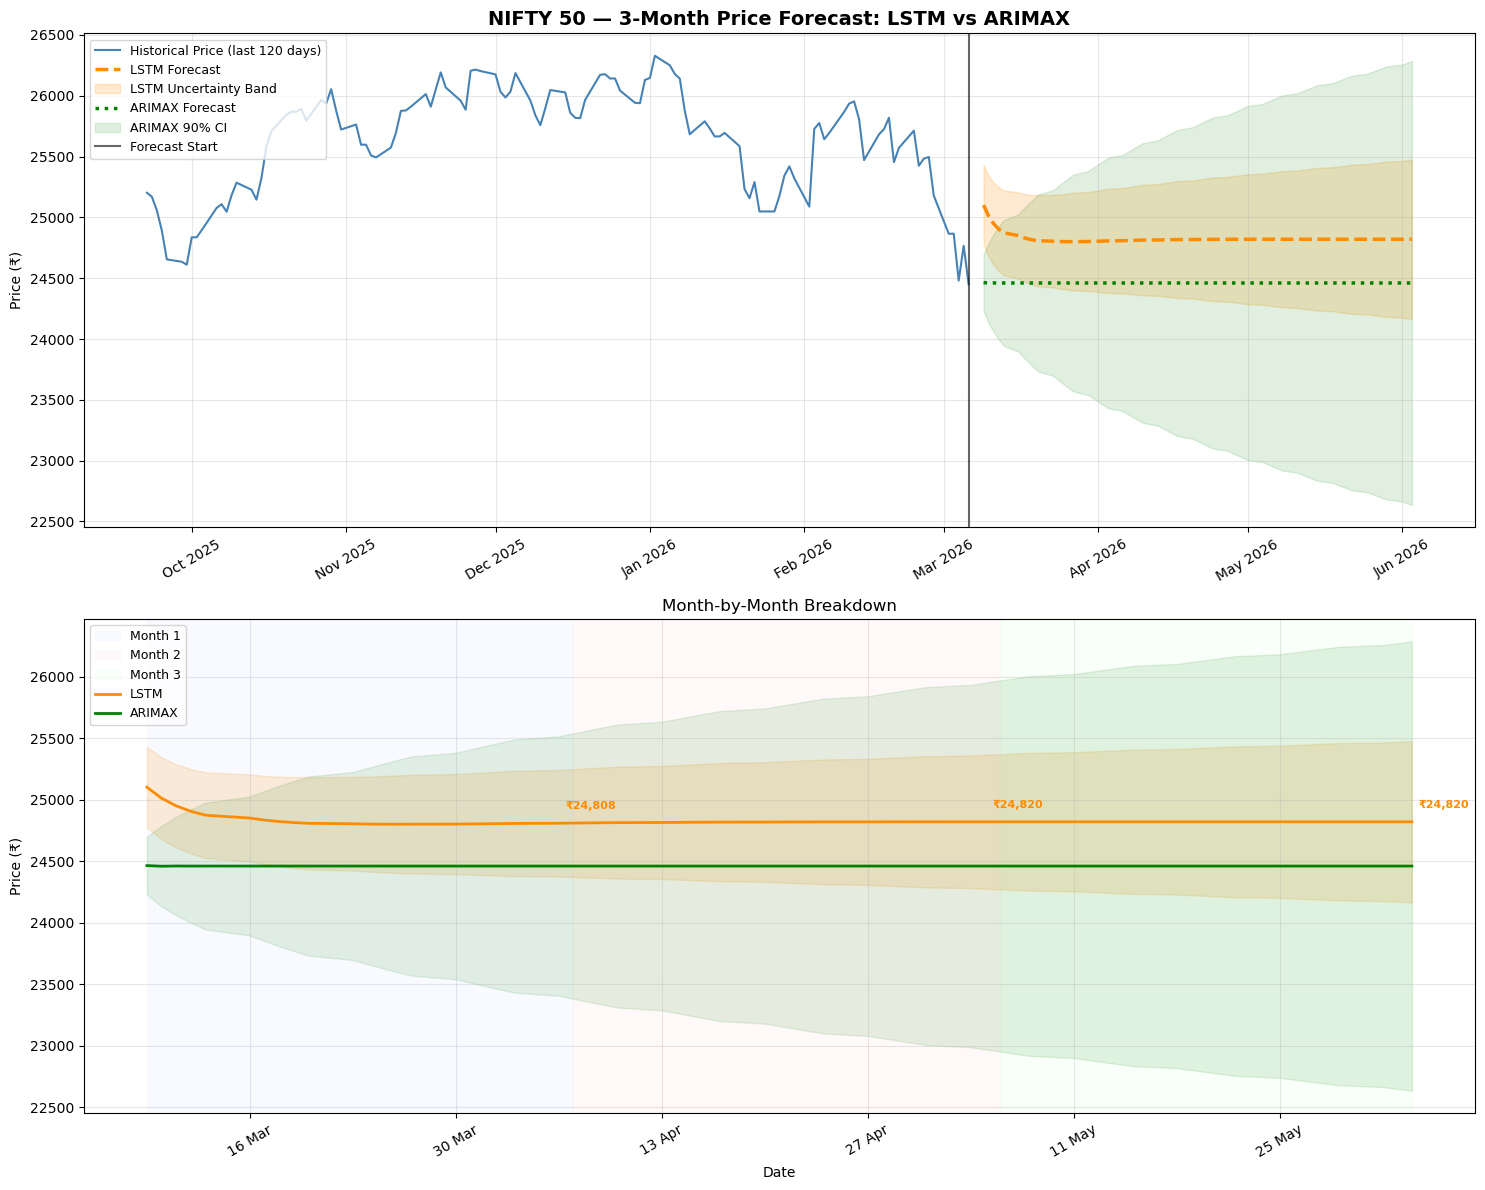

In [61]:
last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.offsets.BDay(1),
                               periods=FORECAST_DAYS)
CONTEXT_DAYS = 120
hist_dates   = df.index[-CONTEXT_DAYS:]
hist_prices  = df['Close'].iloc[-CONTEXT_DAYS:]
fig, axes = plt.subplots(2, 1, figsize=(15, 12))
ax = axes[0]
ax.plot(hist_dates, hist_prices, color='steelblue', linewidth=1.5,
        label='Historical Price (last 120 days)')
ax.plot(future_dates, lstm_future_prices, color='darkorange', linewidth=2.5,
        linestyle='--', label='LSTM Forecast')
ax.fill_between(future_dates, lower_band, upper_band,
                alpha=0.18, color='darkorange', label='LSTM Uncertainty Band')
ax.plot(future_dates, arimax_3m_forecast.values, color='green', linewidth=2.5,
        linestyle=':', label='ARIMAX Forecast')
ax.fill_between(future_dates, arimax_lower, arimax_upper,
                alpha=0.12, color='green', label='ARIMAX 90% CI')
ax.axvline(last_date, color='black', linewidth=1.5, linestyle='-', alpha=0.6,
           label='Forecast Start')
ax.set_title("NIFTY 50 — 3-Month Price Forecast: LSTM vs ARIMAX", fontsize=14, fontweight='bold')
ax.set_ylabel("Price (₹)")
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax2 = axes[1]
month_boundaries = [0, 21, 42, 63]
month_labels     = ['Month 1', 'Month 2', 'Month 3']
month_colors     = ['#f0f4ff', '#fff0f0', '#f0fff0']

for j, (start_d, end_d, label, color) in enumerate(
        zip(month_boundaries[:-1], month_boundaries[1:], month_labels, month_colors)):
    ax2.axvspan(future_dates[start_d],
                future_dates[min(end_d, len(future_dates)-1)],
                alpha=0.4, color=color, label=label)

ax2.plot(future_dates, lstm_future_prices,  color='darkorange', linewidth=2, label='LSTM')
ax2.plot(future_dates, arimax_3m_forecast.values, color='green', linewidth=2, label='ARIMAX')
ax2.fill_between(future_dates, lower_band, upper_band,  alpha=0.15, color='darkorange')
ax2.fill_between(future_dates, arimax_lower, arimax_upper, alpha=0.10, color='green')
for end_d, label in zip(month_boundaries[1:], month_labels):
    idx = min(end_d - 1, FORECAST_DAYS - 1)
    ax2.annotate(f"₹{lstm_future_prices[idx]:,.0f}",
                 xy=(future_dates[idx], lstm_future_prices[idx]),
                 xytext=(5, 10), textcoords='offset points',
                 fontsize=8, color='darkorange', fontweight='bold')

ax2.set_title("Month-by-Month Breakdown", fontsize=12)
ax2.set_ylabel("Price (₹)")
ax2.set_xlabel("Date")
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('3month_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## LSTM 3-Month Forecast (Active Shock)

In [62]:
SHOCK_FACTOR = 0.95

lstm_future_prices_shock = lstm_future_prices * SHOCK_FACTOR

print(f"LSTM 3-month forecast generated: {FORECAST_DAYS} days")
print(f"Last known price : ₹{actual_price[-1]:,.2f}")
print(f"Forecast of Tomorrow : ₹{lstm_future_prices_shock[0]:,.2f}")
print(f"Forecast after 3 month : ₹{lstm_future_prices_shock[-1]:,.2f}")

change_pct_shock = (
    (lstm_future_prices_shock[-1] - actual_price[-1])
    / actual_price[-1]) * 100

direction = "UP" if change_pct_shock > 0 else "DOWN"

print(f"Expected change : {change_pct_shock:+.2f}% {direction}")

LSTM 3-month forecast generated: 63 days
Last known price : ₹24,450.45
Forecast of Tomorrow : ₹23,846.32
Forecast after 3 month : ₹23,579.05
Expected change : -3.56% DOWN


## ARIMAX 3-Month Forecast (Active Shock)

In [63]:
future_shock_active = np.ones(FORECAST_DAYS)
arimax_3m_shock = result_3m_arimax.forecast(steps=FORECAST_DAYS,exog=future_shock_active)
forecast_obj_shock = result_3m_arimax.get_forecast(steps=FORECAST_DAYS,exog=future_shock_active)

conf_int_shock = forecast_obj_shock.conf_int(alpha=0.10)

arimax_shock_lower = conf_int_shock.iloc[:, 0].values
arimax_shock_upper = conf_int_shock.iloc[:, 1].values

print("ARIMAX 3-Month Forecast (Active Shock)")
print(f"Forecast after 3 month : ₹{arimax_3m_shock.iloc[-1]:,.2f}")

shock_change = (
    (arimax_3m_shock.iloc[-1] - df['Close'].iloc[-1])
    / df['Close'].iloc[-1]) * 100

direction = "UP" if shock_change > 0 else "DOWN"

print(f"Expected change: {shock_change:+.2f}% {direction}")

ARIMAX 3-Month Forecast (Active Shock)
Forecast after 3 month : ₹24,224.94
Expected change: -0.92% DOWN


## LSTM vs ARIMAX — Active Shock

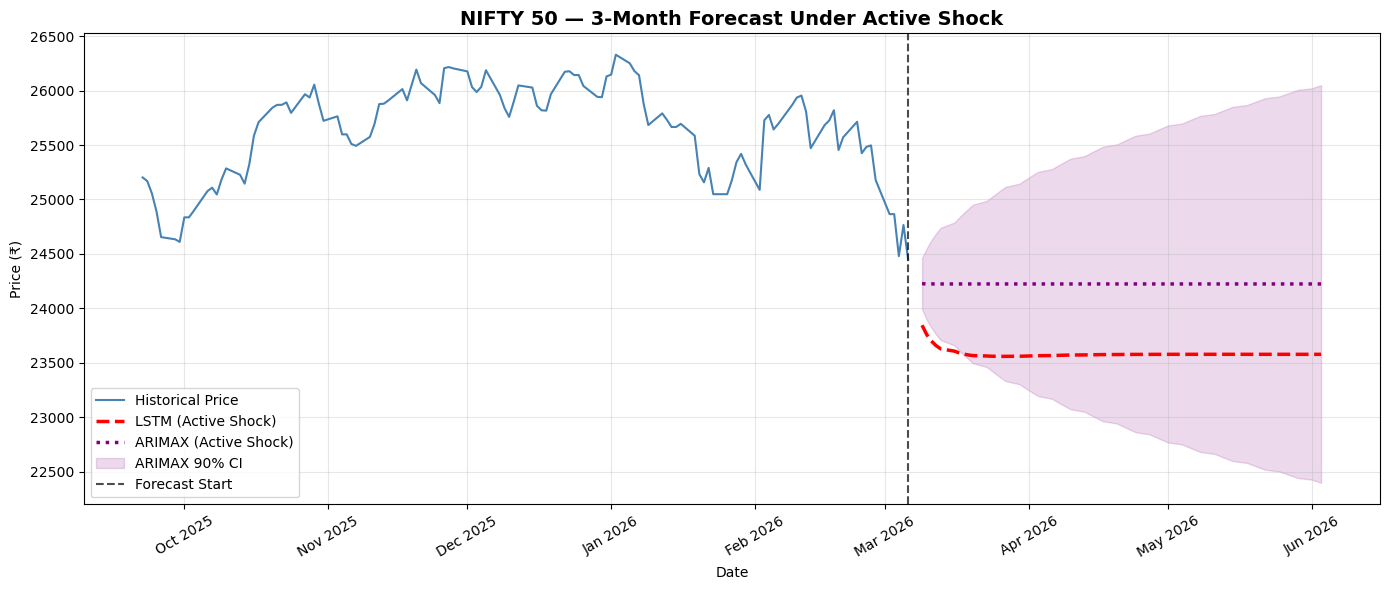

In [64]:
plt.figure(figsize=(14,6))
plt.plot(hist_dates, hist_prices,color='steelblue',linewidth=1.5,
         label='Historical Price')
plt.plot(future_dates,lstm_future_prices_shock,color='red',linewidth=2.5,linestyle='--',
         label='LSTM (Active Shock)')

# ARIMAX Active Shock Forecast
plt.plot(future_dates,arimax_3m_shock.values,color='purple',linewidth=2.5,linestyle=':',
         label='ARIMAX (Active Shock)')

# ARIMAX Confidence Interval
plt.fill_between(future_dates,arimax_shock_lower,arimax_shock_upper,alpha=0.15,color='purple',
                 label='ARIMAX 90% CI')

# Forecast start line
plt.axvline(last_date,color='black',linestyle='--',alpha=0.7,
            label='Forecast Start')

plt.title("NIFTY 50 — 3-Month Forecast Under Active Shock",fontsize=14,fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Prophet

In [65]:
from prophet import Prophet
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [66]:
prophet_df = df[['Close']].reset_index()
prophet_df.columns = ['ds', 'y']
train_size_prophet = int(len(prophet_df) * 0.8)

train_prophet = prophet_df.iloc[:train_size_prophet]
test_prophet  = prophet_df.iloc[train_size_prophet:]

m_prophet = Prophet(daily_seasonality=False,weekly_seasonality=True,yearly_seasonality=True,interval_width=0.90)
m_prophet.fit(train_prophet)
forecast_test = m_prophet.predict(test_prophet[['ds']])
prophet_test_pred = forecast_test['yhat'].values
prophet_actual = test_prophet['y'].values

15:56:49 - cmdstanpy - INFO - Chain [1] start processing
15:56:52 - cmdstanpy - INFO - Chain [1] done processing


In [67]:
rmse_prophet = np.sqrt(mean_squared_error(prophet_actual, prophet_test_pred))
mae_prophet = mean_absolute_error(prophet_actual, prophet_test_pred)
mape_prophet = mean_absolute_percentage_error(prophet_actual, prophet_test_pred) * 100
accuracy_prophet = 100 - mape_prophet
r2_prophet = r2_score(prophet_actual, prophet_test_pred)
print("Prophet Model Evaluation")
print(f"RMSE      : {rmse_prophet:,.2f}")
print(f"MAE       : {mae_prophet:,.2f}")
print(f"MAPE      : {mape_prophet:.2f}%")
print(f"Accuracy  : {accuracy_prophet:.2f}%")
print(f"R² Score  : {r2_prophet:.4f}")

Prophet Model Evaluation
RMSE      : 1,287.98
MAE       : 1,051.49
MAPE      : 4.34%
Accuracy  : 95.66%
R² Score  : -0.2116


In [68]:
future_bdays = pd.bdate_range(start=df.index[-1] + pd.offsets.BDay(1),periods=FORECAST_DAYS)
future_prophet_df = pd.DataFrame({'ds': future_bdays})
forecast_prophet = m_prophet.predict(future_prophet_df)
prophet_future_prices = forecast_prophet['yhat'].values
prophet_lower = forecast_prophet['yhat_lower'].values
prophet_upper = forecast_prophet['yhat_upper'].values

## Prophet 3-Month Forecast (No Active Shock)

In [69]:
prophet_future_prices = forecast_prophet['yhat'].values
prophet_lower = forecast_prophet['yhat_lower'].values
prophet_upper = forecast_prophet['yhat_upper'].values

print("Prophet 3-Month Forecast (No Active Shock)")
print(f"Forecast after 3 month : ₹{prophet_future_prices[-1]:,.2f}")

change = ((prophet_future_prices[-1] - df['Close'].iloc[-1])
          / df['Close'].iloc[-1]) * 100

print(f"Expected Change : {change:+.2f}%")

Prophet 3-Month Forecast (No Active Shock)
Forecast after 3 month : ₹27,462.41
Expected Change : +12.32%


## Prophet 3-Month Forecast (Active Shock)

In [70]:
SHOCK_FACTOR = 0.95
prophet_future_prices_shock = prophet_future_prices * SHOCK_FACTOR
prophet_lower_shock = prophet_lower * SHOCK_FACTOR
prophet_upper_shock = prophet_upper * SHOCK_FACTOR

print("Prophet 3-Month Forecast (Active Shock)")
print(f"Forecast after 3 month : ₹{prophet_future_prices_shock[-1]:,.2f}")

shock_change = ((prophet_future_prices_shock[-1] - df['Close'].iloc[-1])/ df['Close'].iloc[-1]) * 100

direction = "UP" if shock_change > 0 else "DOWN"

print(f"Expected Change : {shock_change:+.2f}% {direction}")

Prophet 3-Month Forecast (Active Shock)
Forecast after 3 month : ₹26,089.29
Expected Change : +6.70% UP


## XGBoost

In [71]:
def add_technical_features(dataframe):

    d = dataframe.copy()

    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = -delta.clip(upper=0).rolling(14).mean()

    rs = gain / loss
    d['RSI'] = 100 - (100 / (1 + rs))

    ema12 = d['Close'].ewm(span=12, adjust=False).mean()
    ema26 = d['Close'].ewm(span=26, adjust=False).mean()

    d['MACD'] = ema12 - ema26
    d['MACD_signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_hist'] = d['MACD'] - d['MACD_signal']

    sma20 = d['Close'].rolling(20).mean()
    std20 = d['Close'].rolling(20).std()

    d['BB_upper'] = sma20 + 2 * std20
    d['BB_lower'] = sma20 - 2 * std20

    d['EMA_10'] = d['Close'].ewm(span=10, adjust=False).mean()
    d['EMA_20'] = d['Close'].ewm(span=20, adjust=False).mean()
    d['EMA_50'] = d['Close'].ewm(span=50, adjust=False).mean()

    for lag in [1, 2, 3, 5, 10, 20]:
        d[f'Close_lag{lag}'] = d['Close'].shift(lag)

    d['rolling_mean_10'] = d['Close'].rolling(10).mean()
    d['rolling_std_10'] = d['Close'].rolling(10).std()
    d['rolling_mean_30'] = d['Close'].rolling(30).mean()

    d['momentum_5'] = d['Close']/d['Close'].shift(5) - 1
    d['momentum_20'] = d['Close']/d['Close'].shift(20) - 1

    return d

In [72]:
df_feat = add_technical_features(df).dropna()

feature_cols = [c for c in df_feat.columns
                if c not in ['Close','Return','Log_Return','Volatility','rolling_volatility','Close_diff','shock']]

X_xgb = df_feat[feature_cols].values
y_xgb = df_feat['Close'].values

In [73]:
split_xgb = int(len(X_xgb) * 0.8)
X_tr, X_te = X_xgb[:split_xgb], X_xgb[split_xgb:]
y_tr, y_te = y_xgb[:split_xgb], y_xgb[split_xgb:]

In [74]:
xgb_model = XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=5,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgb_model.fit(X_tr, y_tr)
xgb_test_pred = xgb_model.predict(X_te)

In [75]:
from sklearn.metrics import *

rmse_xgb = np.sqrt(mean_squared_error(y_te, xgb_test_pred))
mae_xgb = mean_absolute_error(y_te, xgb_test_pred)
mape_xgb = mean_absolute_percentage_error(y_te, xgb_test_pred) * 100
accuracy_xgb = 100 - mape_xgb
r2_xgb = r2_score(y_te, xgb_test_pred)

print("XGBoost Model Evaluation")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2f}%")
print(f"Accuracy: {accuracy_xgb:.2f}%")
print(f"R2 Score: {r2_xgb:.4f}")

XGBoost Model Evaluation
RMSE: 2410.43
MAE: 2134.54
MAPE: 8.55%
Accuracy: 91.45%
R2 Score: -3.4125


In [76]:
FORECAST_DAYS = 63

df_future_xgb = df_feat.copy()

xgb_future_prices = []

for day in range(FORECAST_DAYS):
    last_features = add_technical_features(df_future_xgb).dropna().iloc[[-1]][feature_cols].values
    next_price = xgb_model.predict(last_features)[0]
    xgb_future_prices.append(next_price)
    new_row = df_future_xgb.iloc[-1].copy()
    new_row['Open'] = next_price
    new_row['High'] = next_price * 1.005
    new_row['Low']  = next_price * 0.995
    new_row['Close'] = next_price

    new_row.name = (df_future_xgb.index[-1]+ pd.offsets.BDay(1))
    df_future_xgb = pd.concat([df_future_xgb, new_row.to_frame().T])

xgb_future_prices = np.array(xgb_future_prices)

xgb_residual_std = np.std(y_te - xgb_test_pred)

xgb_widening = np.linspace(1.0,2.0,FORECAST_DAYS)

xgb_upper = (xgb_future_prices+ xgb_widening * xgb_residual_std)

xgb_lower = (xgb_future_prices- xgb_widening * xgb_residual_std)

## XGBoost 3-Month Forecast (No Active Shock)

In [77]:
print(f"Forecast after 3 month : ₹{xgb_future_prices[-1]:,.2f}")
xgb_change = ((xgb_future_prices[-1] - df['Close'].iloc[-1])/ df['Close'].iloc[-1]) * 100
direction = "Bullish" if xgb_change > 0 else "Bearish"
print(f"Expected change : {xgb_change:+.2f}% {direction}")

Forecast after 3 month : ₹20,854.27
Expected change : -14.71% Bearish


## XGBoost 3-Month Forecast (Active Shock)

In [78]:
SHOCK_FACTOR = 0.95
xgb_future_prices_shock = xgb_future_prices * SHOCK_FACTOR
xgb_upper_shock = xgb_upper * SHOCK_FACTOR
xgb_lower_shock = xgb_lower * SHOCK_FACTOR

print(f"Forecast after 3 month : ₹{xgb_future_prices_shock[-1]:,.2f}")

shock_change = ((xgb_future_prices_shock[-1] - df['Close'].iloc[-1])/ df['Close'].iloc[-1]) * 100
direction = "Bullish" if shock_change > 0 else "Bearish"
print(f"Expected change : {shock_change:+.2f}% {direction}")

Forecast after 3 month : ₹19,811.56
Expected change : -18.97% Bearish


## 4-MODEL ACTIVE SHOCK FORECAST PLOT

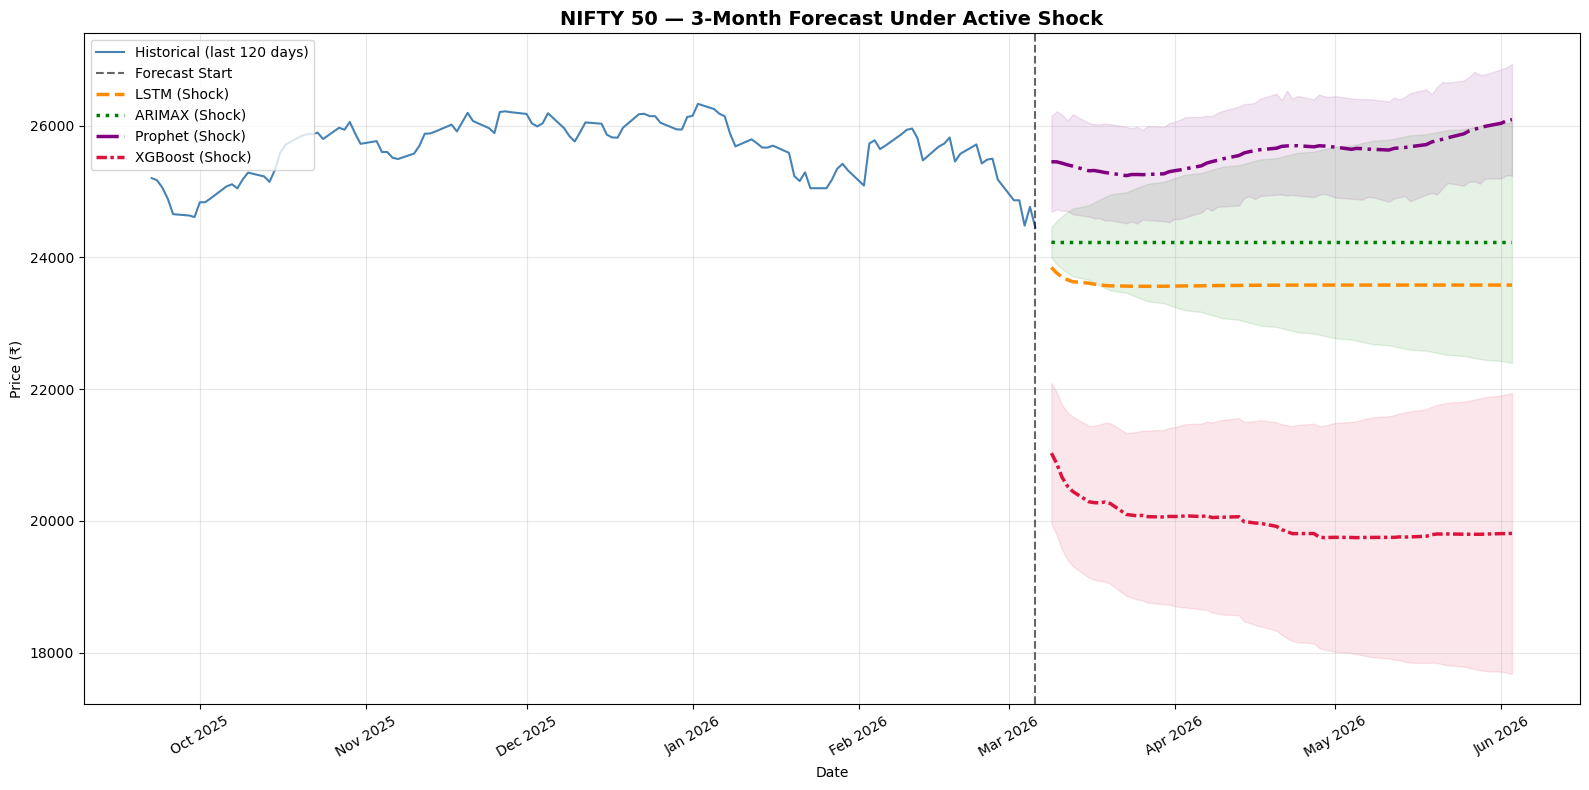

In [79]:
plt.figure(figsize=(16,8))
plt.plot(hist_dates, hist_prices,color='steelblue',linewidth=1.5,
         label='Historical (last 120 days)')
plt.axvline(last_date,color='black',linestyle='--',alpha=0.6,
            label='Forecast Start')

# LSTM Active Shock
plt.plot(future_dates,lstm_future_prices_shock,color='darkorange',linewidth=2.5,linestyle='--',
         label='LSTM (Shock)')

# ARIMAX Active Shock
plt.plot(future_dates,arimax_3m_shock.values,color='green',linewidth=2.5,linestyle=':',label='ARIMAX (Shock)')

plt.fill_between(future_dates,arimax_shock_lower,arimax_shock_upper,alpha=0.10,color='green')

# Prophet Active Shock
plt.plot(future_dates,prophet_future_prices_shock,color='purple',linewidth=2.5,linestyle='-.',label='Prophet (Shock)')

plt.fill_between(future_dates,prophet_lower_shock,prophet_upper_shock,alpha=0.10,color='purple')

# XGBoost Active Shock
plt.plot(future_dates,xgb_future_prices_shock,color='crimson',linewidth=2.5,linestyle=(0,(3,1,1,1)),
         label='XGBoost (Shock)')

plt.fill_between(future_dates,xgb_lower_shock,xgb_upper_shock,alpha=0.10,color='crimson')

plt.title("NIFTY 50 — 3-Month Forecast Under Active Shock",fontsize=14,fontweight='bold')

plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('4model_active_shock_forecast.png',dpi=150,bbox_inches='tight')
plt.show()

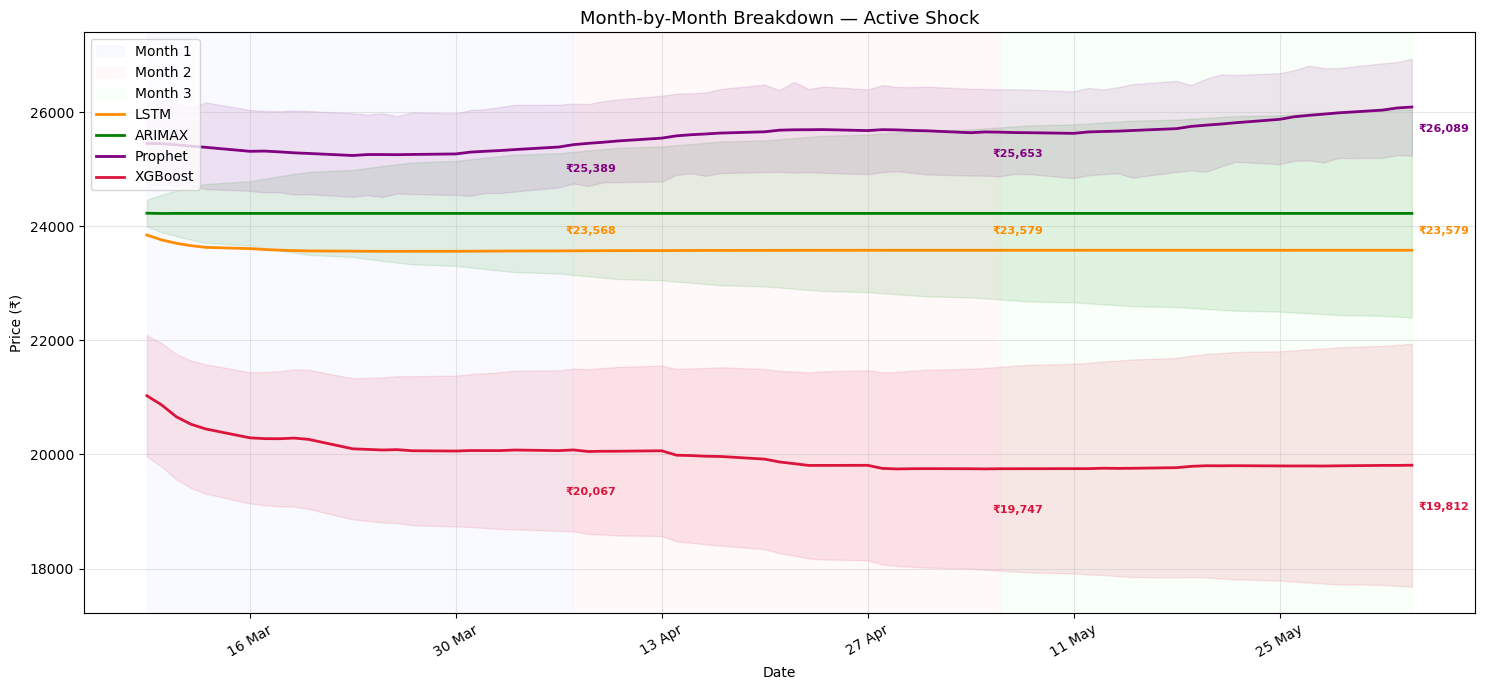

In [80]:
plt.figure(figsize=(15, 7))

month_boundaries= [0, 21, 42, 63]
month_labels= ['Month 1', 'Month 2', 'Month 3']
month_colors= ['#f0f4ff', '#fff0f0', '#f0fff0']

for start_d, end_d, label, color in zip(month_boundaries[:-1],month_boundaries[1:],month_labels,month_colors):
    plt.axvspan(future_dates[start_d],future_dates[min(end_d, len(future_dates)-1)],alpha=0.4,color=color,
        label=label)

# 4 Model Forecasts (Active Shock)
plt.plot(future_dates, lstm_future_prices_shock,
         color='darkorange', linewidth=2, label='LSTM')

plt.plot(future_dates, arimax_3m_shock.values,
         color='green', linewidth=2, label='ARIMAX')

plt.plot(future_dates, prophet_future_prices_shock,
         color='purple', linewidth=2, label='Prophet')

plt.plot(future_dates, xgb_future_prices_shock,
         color='crimson', linewidth=2, label='XGBoost')

# Confidence Intervals
plt.fill_between(future_dates,arimax_shock_lower,arimax_shock_upper,alpha=0.10,color='green')

plt.fill_between(future_dates,prophet_lower_shock,prophet_upper_shock,alpha=0.10,color='purple')

plt.fill_between(future_dates,xgb_lower_shock,xgb_upper_shock,alpha=0.10,color='crimson')

# Month-end predicted price labels
for end_d in month_boundaries[1:]:
    idx = min(end_d - 1, FORECAST_DAYS - 1)

    for prices, color, offset in [(lstm_future_prices_shock, 'darkorange', 12),(prophet_future_prices_shock, 'purple', -18),
        (xgb_future_prices_shock, 'crimson', -32),]:
        plt.annotate(f"₹{prices[idx]:,.0f}",xy=(future_dates[idx], prices[idx]),xytext=(5, offset),textcoords='offset points',
                     fontsize=8,color=color,fontweight='bold')

plt.title("Month-by-Month Breakdown — Active Shock", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Now COMPARING With ACTUAL DATA

### Step 1: Load Actual NIFTY 50 Data

In [81]:
actual_df = pd.read_csv("NIFTY 50-07-03-2026-to-07-06-2026.csv")
actual_df.columns = actual_df.columns.str.strip()
actual_df['Date'] = pd.to_datetime(actual_df['Date'],format='%d-%b-%Y')
actual_df = actual_df.sort_values('Date')
actual_dates = actual_df['Date']
actual_prices = actual_df['Close'].values
print("Actual Trading Days:", len(actual_prices))

Actual Trading Days: 59


### Step 2: Align Actual Data with Active Shock Forecasts

In [82]:
N = min(len(actual_prices),len(lstm_future_prices_shock))
actual_prices = actual_prices[:N]
actual_dates = actual_dates[:N]

lstm_sh = lstm_future_prices_shock[:N]
arimax_sh = arimax_3m_shock.values[:N]
prophet_sh = prophet_future_prices_shock[:N]
xgb_sh = xgb_future_prices_shock[:N]

### Step 3: Evaluation Function

In [83]:
def evaluate_model(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    accuracy = 100 - mape
    r2 = r2_score(actual, predicted )
    return rmse, mae, mape, accuracy, r2

### Step 4: Compare All Active Shock Models

In [84]:
results = []

for name, pred in [("LSTM", lstm_sh),("ARIMAX", arimax_sh),("Prophet", prophet_sh),("XGBoost", xgb_sh)]:
    rmse, mae, mape, acc, r2 = evaluate_model(actual_prices,pred)
    results.append([name,rmse,mae,mape,acc,r2])
comparison_df = pd.DataFrame(
    results,
    columns=["Model","RMSE","MAE","MAPE (%)","Accuracy (%)","R2 Score"])

print("\nACTIVE SHOCK VALIDATION")
print(comparison_df.round(2))


ACTIVE SHOCK VALIDATION
     Model     RMSE      MAE  MAPE (%)  Accuracy (%)  R2 Score
0     LSTM   508.46   417.79      1.77         98.23     -0.00
1   ARIMAX   746.77   582.08      2.50         97.50     -1.16
2  Prophet  1928.06  1873.54      7.95         92.05    -13.40
3  XGBoost  3731.86  3682.82     15.51         84.49    -52.95


### Step5: PLOT ACTUAL vs NO ACTIVE SHOCK FORECASTS

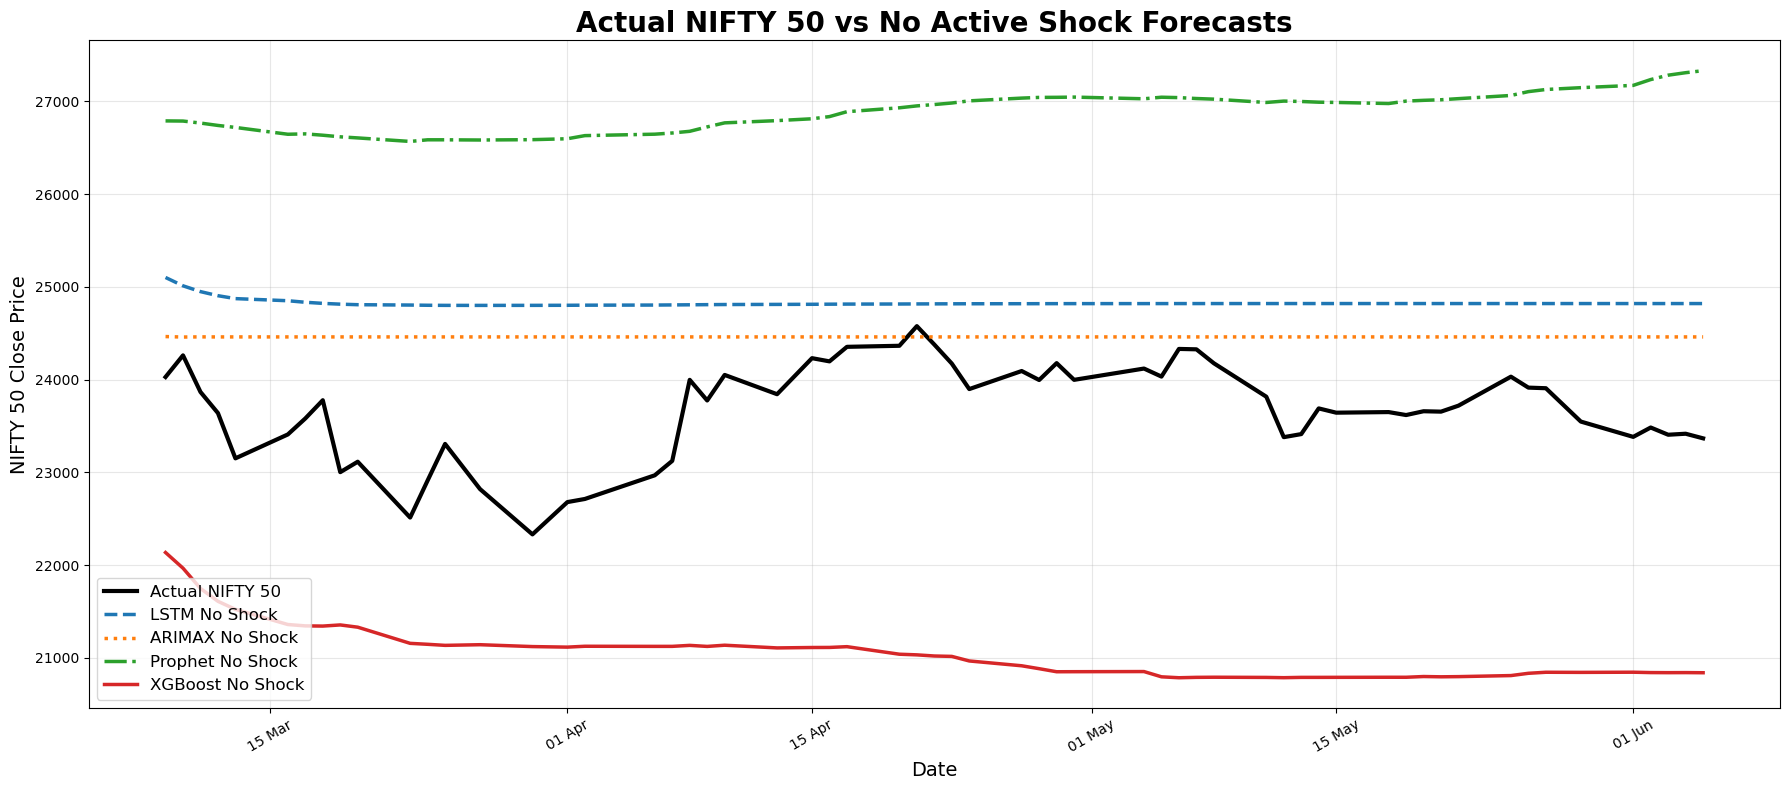

In [85]:
lstm_ns    = lstm_future_prices[:N]
arimax_ns  = arimax_3m_forecast.values[:N]
prophet_ns = prophet_future_prices[:N]
xgb_ns     = xgb_future_prices[:N]

plt.figure(figsize=(18, 8))

plt.plot(actual_dates, actual_prices,color='black', linewidth=3,
         label='Actual NIFTY 50')

plt.plot(actual_dates, lstm_ns,'--', linewidth=2.5,
         label='LSTM No Shock')

plt.plot(actual_dates, arimax_ns,':', linewidth=2.5,
         label='ARIMAX No Shock')

plt.plot(actual_dates, prophet_ns,'-.', linewidth=2.5,
         label='Prophet No Shock')

plt.plot(actual_dates, xgb_ns,linewidth=2.5,
         label='XGBoost No Shock')

plt.title('Actual NIFTY 50 vs No Active Shock Forecasts',
          fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('NIFTY 50 Close Price', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Step 6: Plot Actual vs Active Shock Forecasts

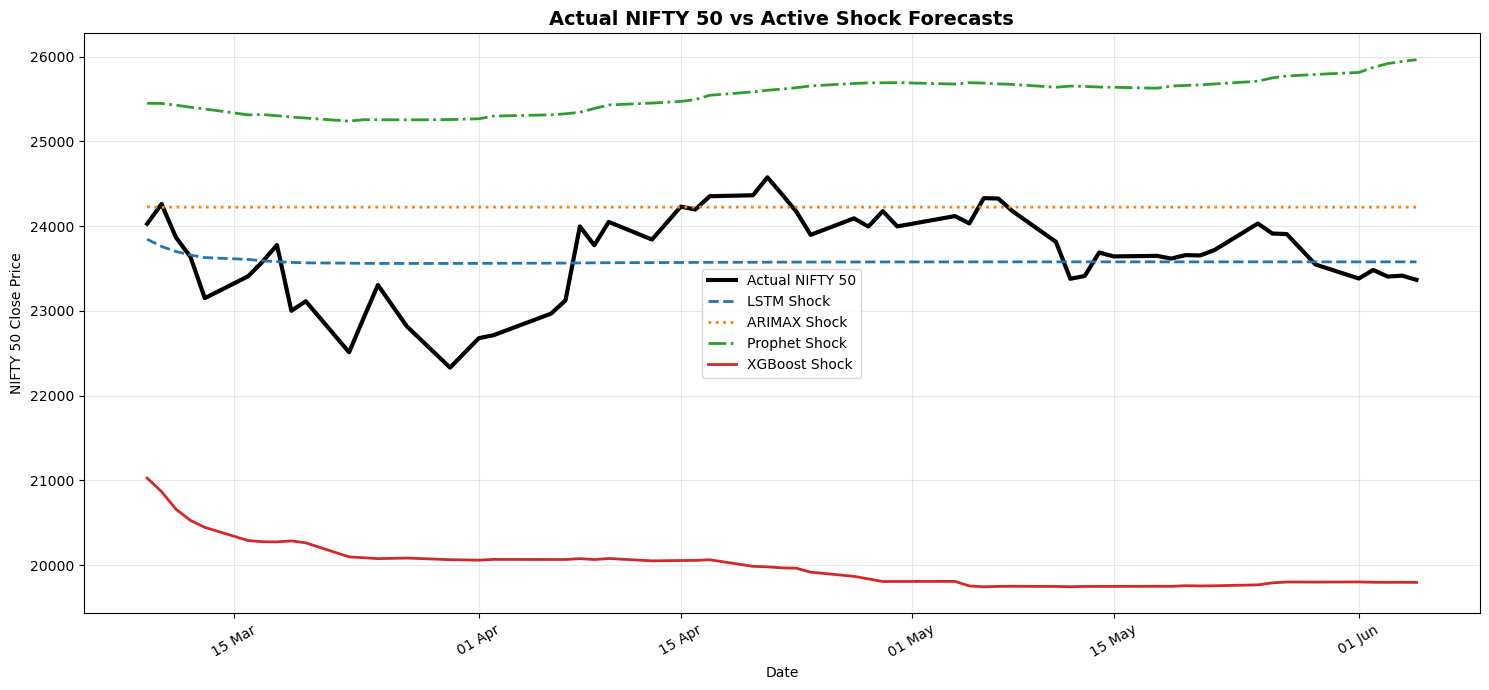

In [86]:
plt.figure(figsize=(15,7))

plt.plot(actual_dates,actual_prices,color='black',linewidth=3,label='Actual NIFTY 50')
plt.plot(actual_dates,lstm_sh,'--',linewidth=2,label='LSTM Shock')
plt.plot(actual_dates,arimax_sh,':',linewidth=2,
    label='ARIMAX Shock')

plt.plot(actual_dates, prophet_sh, '-.', linewidth=2,
    label='Prophet Shock')

plt.plot(actual_dates,xgb_sh,linewidth=2,
    label='XGBoost Shock')

plt.title("Actual NIFTY 50 vs Active Shock Forecasts",fontsize=14,fontweight='bold')

plt.xlabel("Date")
plt.ylabel("NIFTY 50 Close Price")
plt.legend()
plt.grid(alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Step 7: Best ModelStep 6: Best Model

In [87]:
best_model = comparison_df.loc[comparison_df['RMSE'].idxmin(),'Model']
print("\nBest Active Shock Model:", best_model)


Best Active Shock Model: LSTM
